# Title: XRL for Optimising Battery Schedules

**Stage 1 — TFT Forecasting** \
Trained a Temporal Fusion Transformer (Model 3) on German EPEX DAM prices (2022–2023 train, 2024 val). The model outputs p10/p50/p90 quantile forecasts for 36 hours ahead. Ran inference over the full 2022–2025 dataset using a sliding window, extracted positions [12:35] corresponding to Day-D hours 00:00–23:00, and saved 72 forecast columns into an augmented CSV.

**Stage 2 — RL Training (4 conditions)** \
Trained DQN and PPO agents in baseline and TFT-augmented configurations. The TFT conditions used the augmented CSV — the 72 forecast columns were added directly to the state space (20 baseline features + 72 TFT = 92 + soc = 93 dims). No runtime inference — forecasts were pre-computed. Result: DQN+TFT (+23.6% over DQN baseline).

**Stage 3 — XRL Explainability** \
Loaded the best DQN+TFT checkpoint, reconstructed the environment with the augmented CSV, ran DeepSHAP on the Q-network to attribute feature importance, and decomposed the hourly P&L to understand when and why the agent makes profitable decisions. Two visualisations: global feature importance (which inputs drive decisions) and hourly P&L (when in the day value is created and destroyed).


**Expected runtime on A100:** ~50–60 minutes for 10 epochs on 2022–2023

**Stage 1: Building a Temporal Fusion Transformer Model for Predictions**

- Loads `TFT_final_data.xlsx` already uploaded to Colab
- Cleans and prepares data for PyTorch Forecasting
- Trains TFT with p10/p50/p90 quantile outputs on 2022–2023 data
- Validates on 2024 data
- Plots the quantile forecast band
- Saves checkpoint to Google Drive



In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — Install dependencies
# Run once. Takes 3-4 minutes.
# ═══════════════════════════════════════════════════════════════════

!pip install -q "numpy==1.26.4"
!pip install -q "pytorch-forecasting==1.1.1"
!pip install -q "lightning==2.3.0"
!pip install -q openpyxl

import torch
print('PyTorch version:', torch.__version__)
print('CUDA available: ', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:            ', torch.cuda.get_device_name(0))
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU Memory:      {mem:.1f} GB')
print()
print('Installation complete.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 103.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 re

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — Mount Google Drive
# All outputs (checkpoint, plots, metrics) save here permanently.
# Even if Colab disconnects your results are safe.
# ═══════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os

# All TFT outputs go here — change folder name if you want
DRIVE_SAVE_DIR = '/content/drive/MyDrive/thesis_battery_xrl/tft_outputs'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

print(f'Output directory: {DRIVE_SAVE_DIR}')
print(f'Contents so far:  {os.listdir(DRIVE_SAVE_DIR)}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs
Contents so far:  ['tft_training_log', 'tft_best_epoch=02_val_loss=11.9160.ckpt', 'tft_quantile_forecasts.png', 'tft_uncertainty_band_2024.png', 'tft_forecast_quality.png', 'tft_v2_log', 'tft_v2_best_epoch=03_val_loss=16.0121.ckpt', 'best_checkpoint_path_v2.txt', 'tft_dam36_log', 'tft_dam36_best_epoch=03_val_loss=15.2656.ckpt', 'dam_forecast_quality.png', 'tft_correct_log', 'tft_correct_best_epoch=04_val_loss=12.4029.ckpt', 'best_checkpoint_correct.txt', 'tft_best_log', 'tft_best_final_epoch=00_val_loss=15.5938.ckpt', 'best_checkpoint_final.txt', 'tft_best_epoch=02_val_loss=12.5970.ckpt', 'tft_model.pt', 'tft_best_epoch=03_val_loss=13.5952.ckpt', 'best_checkpoint_path.txt', 'market_overview_2022_2025.png', 'tft_dam36_best_epoch=01_val_loss=11.1913.ckpt', 'best_checkpoint_dam36.txt', 'tft_loss_curves.png', 'tft_final_log', 'tft_final_epoch=07_val_loss=14.5195.ckpt', 'tft_final_epoch=04_val_

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — Load and prepare data
# Reads TFT_final_data.xlsx, renames columns to match
# what the forecaster expects, adds time_idx and group_id.
# ═══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load Excel file ───────────────────────────────────────────────
EXCEL_PATH = '/content/TFT_final_data.xlsx'
print('Loading Excel file...')
df_raw = pd.read_excel(EXCEL_PATH, sheet_name='Final_dataset')
print(f'Raw shape: {df_raw.shape}')
print(f'Columns:   {df_raw.columns.tolist()}')
print()

# ── Rename columns to match forecaster expectations ───────────────
df = df_raw.rename(columns={
    'DAM_yt':            'pool_price',       # target variable
    'Average_DE/LU_t1':  'AvgNeighbour_t1',  # neighbour price lag
    'Average_DE/LU_t2':  'AvgNeighbour_t2',
    'Average_DE/LU_t3':  'AvgNeighbour_t3',
    'Average_DE/LU_t4':  'AvgNeighbour_t4',
    'Average_DE/LU_t5':  'AvgNeighbour_t5',
    'hour\n(0-23)':      'hour',
    'weekday\n(0=Mon)':  'weekday',
    'month\n(1-12)':     'month',
})

# ── Parse timestamps ──────────────────────────────────────────────
df['timestamp'] = pd.to_datetime(df['Ts_from'], format='%d.%m.%Y %H:%M')
df['year']      = df['timestamp'].dt.year

# ── Add required PTF columns ──────────────────────────────────────
df['time_idx'] = range(len(df))   # strict monotonic integer
df['group_id'] = 'DE_LU'          # single series identifier

# Cyclic encoding of calendar features
df['sin_hour']    = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour']    = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_weekday'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['cos_weekday'] = np.cos(2 * np.pi * df['weekday'] / 7)
df['sin_month']   = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['cos_month']   = np.cos(2 * np.pi * (df['month'] - 1) / 12)

# ── Verify ───────────────────────────────────────────────────────
print('After renaming:')
print(f'  pool_price present:       {"pool_price" in df.columns}')
print(f'  AvgNeighbour_t1 present:  {"AvgNeighbour_t1" in df.columns}')
print(f'  time_idx present:         {"time_idx" in df.columns}')
print(f'  group_id present:         {"group_id" in df.columns}')
print(f'  Missing values:           {df.isnull().sum().sum()}')
print()
print(f'Date range: {df.timestamp.iloc[0]} → {df.timestamp.iloc[-1]}')
print()

# ── Price stats by year ───────────────────────────────────────────
print('DAM price by year:')
print(df.groupby('year')['pool_price'].agg(['mean','std','min','max']).round(1))

Loading Excel file...
Raw shape: (35040, 27)
Columns:   ['Ts_from', 'Ts_to', 'DAM_yt', 'DAM_t1', 'Average_DE/LU_t1', 'DAM_t2', 'Average_DE/LU_t2', 'DAM_t3', 'Average_DE/LU_t3', 'DAM_t4', 'Average_DE/LU_t4', 'DAM_t5', 'Average_DE/LU_t5', 'Wind_offshore_t1', 'Wind_onshore_t1', 'Solar_t1', 'sin_hour', 'cos_hour', 'sin_weekday', 'cos_weekday', 'sin_month', 'cos_month', 'hour\n(0-23)', 'weekday\n(0=Mon)', 'month\n(1-12)', 'Net_load_t1', 'Residual_load_t1']

After renaming:
  pool_price present:       True
  AvgNeighbour_t1 present:  True
  time_idx present:         True
  group_id present:         True
  Missing values:           0

Date range: 2022-01-02 00:00:00 → 2025-12-31 23:00:00

DAM price by year:
       mean    std    min    max
year                            
2022  235.9  142.8  -19.0  871.0
2023   95.2   47.6 -500.0  524.3
2024   78.5   52.7 -135.4  936.3
2025   89.3   52.1 -250.3  583.4


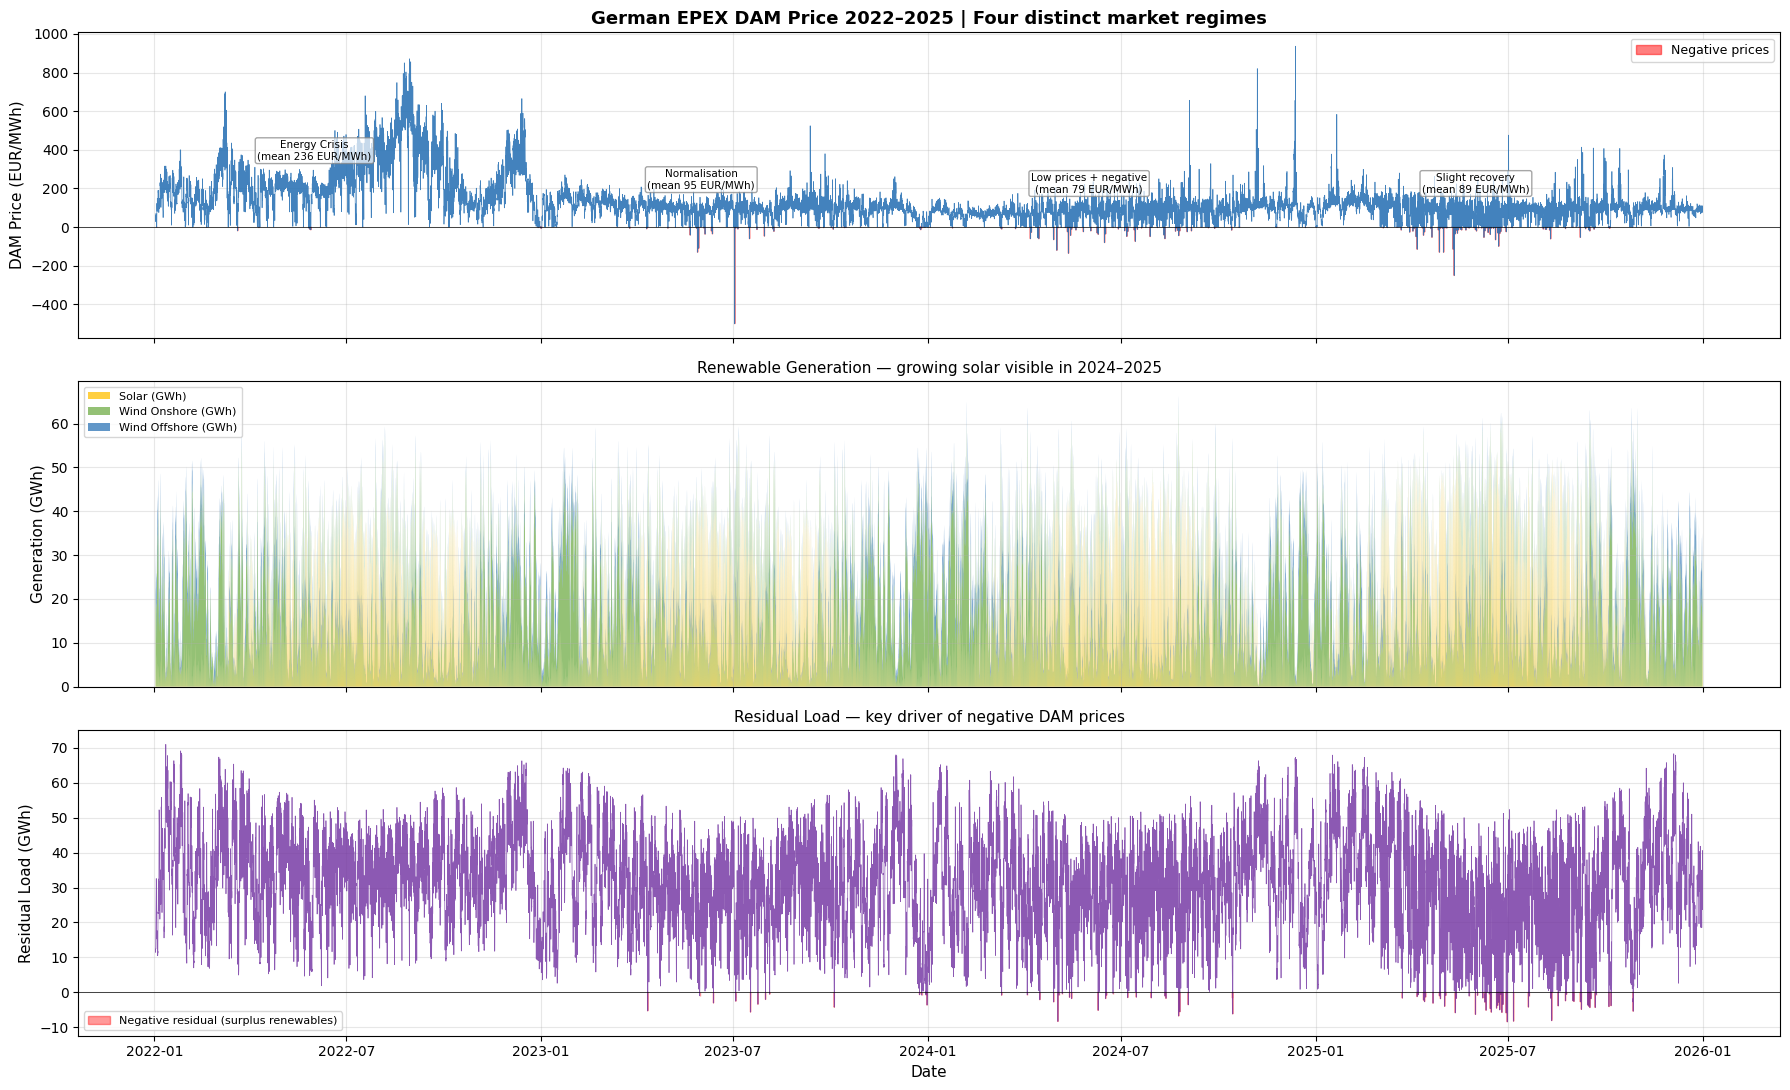

Saved: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/market_overview_2022_2025.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — Market overview plot
# Saves to Drive. This is your first presentation visual.
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)

# DAM price
ax = axes[0]
ax.plot(df['timestamp'], df['pool_price'],
        color='#2E75B6', linewidth=0.5, alpha=0.9)
ax.fill_between(df['timestamp'], df['pool_price'], 0,
                where=df['pool_price'] < 0,
                color='#FF0000', alpha=0.5, label='Negative prices')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('DAM Price (EUR/MWh)', fontsize=11)
ax.set_title(
    'German EPEX DAM Price 2022–2025 | Four distinct market regimes',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Annotate regimes
regime_labels = [
    ('2022', '2022-06-01', 350, 'Energy Crisis\n(mean 236 EUR/MWh)'),
    ('2023', '2023-06-01', 200, 'Normalisation\n(mean 95 EUR/MWh)'),
    ('2024', '2024-06-01', 180, 'Low prices + negative\n(mean 79 EUR/MWh)'),
    ('2025', '2025-06-01', 180, 'Slight recovery\n(mean 89 EUR/MWh)'),
]
for _, ts_str, y_pos, label in regime_labels:
    ax.annotate(label,
                xy=(pd.Timestamp(ts_str), y_pos),
                fontsize=7.5, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.7, edgecolor='grey'))

# Renewables
ax = axes[1]
ax.stackplot(
    df['timestamp'],
    df['Solar_t1'] / 1000,
    df['Wind_onshore_t1'] / 1000,
    df['Wind_offshore_t1'] / 1000,
    labels=['Solar (GWh)', 'Wind Onshore (GWh)', 'Wind Offshore (GWh)'],
    colors=['#FFC000', '#70AD47', '#2E75B6'], alpha=0.75
)
ax.set_ylabel('Generation (GWh)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.set_title('Renewable Generation — growing solar visible in 2024–2025',
             fontsize=11)
ax.grid(alpha=0.3)

# Residual load
ax = axes[2]
ax.plot(df['timestamp'], df['Residual_load_t1'] / 1000,
        color='#7030A0', linewidth=0.5, alpha=0.8)
ax.fill_between(df['timestamp'], df['Residual_load_t1'] / 1000, 0,
                where=df['Residual_load_t1'] < 0,
                color='#FF0000', alpha=0.4,
                label='Negative residual (surplus renewables)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Residual Load (GWh)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Residual Load — key driver of negative DAM prices', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(DRIVE_SAVE_DIR, 'market_overview_2022_2025.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — Build train / val / test splits
# Train:  2022-01-02 to 2023-12-31  (17,472 rows)
# Val:    2024-01-01 to 2024-12-31  (8,784 rows)
# Test:   2025-01-01 to 2025-12-31  (8,760 rows — held out)
#
# Using 2022+2023 for training gives two full market regimes
# (energy crisis + normalisation) for a meaningful demo.
# ═══════════════════════════════════════════════════════════════════
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import EncoderNormalizer, GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# ── Constants ─────────────────────────────────────────────────────
QUANTILES        = [0.1, 0.5, 0.9]   # p10, p50, p90
FORECAST_HORIZON = 24                 # predict 24 hours ahead
ENCODER_LENGTH   = 168                # 1 week of context
BATCH_SIZE       = 64
MAX_EPOCHS       = 50                 # 10 for tonight demo; use 30 for thesis

# ── Feature groups ────────────────────────────────────────────────
# Known in future — calendar features, always available
TIME_VARYING_KNOWN = [
    'sin_hour', 'cos_hour',
    'sin_weekday', 'cos_weekday',
    'sin_month', 'cos_month',
]

# Unknown in future — lags and physical observations
TIME_VARYING_UNKNOWN = [
    'DAM_t1', 'DAM_t2', 'DAM_t3', 'DAM_t4', 'DAM_t5',
    'AvgNeighbour_t1',
    'Wind_offshore_t1', 'Wind_onshore_t1',
    'Solar_t1',
    'Net_load_t1', 'Residual_load_t1',
]

# ── Split by time_idx ─────────────────────────────────────────────
# 2022+2023 = rows 0 to 17471
# 2024      = rows 17472 to 26255  (used for validation)
# 2025      = rows 26256 onwards   (held out — not used today)

train_cutoff = df[df['year'] <= 2023]['time_idx'].max()
val_cutoff   = df[df['year'] <= 2024]['time_idx'].max()

df_train = df[df['time_idx'] <= train_cutoff].copy()
df_val   = df[(df['time_idx'] > train_cutoff) &
               (df['time_idx'] <= val_cutoff)].copy()

print(f'Train: {len(df_train):,} rows | '
      f'{df_train.timestamp.iloc[0].date()} → {df_train.timestamp.iloc[-1].date()}')
print(f'Val:   {len(df_val):,}  rows | '
      f'{df_val.timestamp.iloc[0].date()} → {df_val.timestamp.iloc[-1].date()}')
print()

# ── Build TimeSeriesDataSet ───────────────────────────────────────
print('Building TimeSeriesDataSet...')

training = TimeSeriesDataSet(
    df_train,
    time_idx='time_idx',
    target='pool_price',
    group_ids=['group_id'],
    min_encoder_length=ENCODER_LENGTH // 2,   # at least 84h of context
    max_encoder_length=ENCODER_LENGTH,        # at most 168h of context
    min_prediction_length=FORECAST_HORIZON,
    max_prediction_length=FORECAST_HORIZON,
    time_varying_known_reals=TIME_VARYING_KNOWN,
    time_varying_unknown_reals=TIME_VARYING_UNKNOWN + ['pool_price'],
    target_normalizer=EncoderNormalizer(
        method='robust',    # median/IQR — robust to 2022 price spikes
        center=True,
    ),
    scalers={
        col: GroupNormalizer(groups=['group_id'])
        for col in TIME_VARYING_UNKNOWN
    },
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,   # handles DST gaps cleanly
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df_val,
    predict=True,
    stop_randomization=True,
)

# ── Dataloaders ───────────────────────────────────────────────────
# num_workers=2 on Colab A100 for parallel data loading
train_loader = training.to_dataloader(
    train=True, batch_size=BATCH_SIZE,
    num_workers=2, shuffle=True,
)
val_loader = validation.to_dataloader(
    train=False, batch_size=BATCH_SIZE,
    num_workers=2, shuffle=False,
)

print(f'Training samples:   {len(training):,}')
print(f'Validation samples: {len(validation):,}')
print(f'Batches per epoch:  {len(train_loader):,}')
print()
print(f'Estimated time per epoch on A100: '
      f'~{len(train_loader) * 0.010:.0f} minutes')
print(f'Estimated total for {MAX_EPOCHS} epochs: '
      f'~{len(train_loader) * 0.010 * MAX_EPOCHS:.0f} minutes')

Train: 17,496 rows | 2022-01-02 → 2023-12-31
Val:   8,784  rows | 2024-01-01 → 2024-12-31

Building TimeSeriesDataSet...
Training samples:   17,473
Validation samples: 1
Batches per epoch:  273

Estimated time per epoch on A100: ~3 minutes
Estimated total for 50 epochs: ~136 minutes


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — Build TFT model
# ═══════════════════════════════════════════════════════════════════
from pytorch_forecasting import TemporalFusionTransformer

tft = TemporalFusionTransformer.from_dataset(
    training,
    # Architecture
    hidden_size=64,              # model width
    attention_head_size=4,       # multi-head attention heads
    dropout=0.1,
    hidden_continuous_size=16,   # continuous variable embedding size
    # Training
    loss=QuantileLoss(quantiles=QUANTILES),
    learning_rate=3e-3,
    reduce_on_plateau_patience=4,
    optimizer='adam',
    log_interval=10,
)

n_params = sum(p.numel() for p in tft.parameters() if p.requires_grad)
print(f'TFT model built.')
print(f'Trainable parameters: {n_params:,}')
print(f'Forecast horizon:     {FORECAST_HORIZON}h')
print(f'Encoder length:       {ENCODER_LENGTH}h (1 week context)')
print(f'Quantiles:            {QUANTILES}  →  p10, p50, p90')
print()
print('Variable importances will be available after training:')
print('  Encoder variables (time-varying unknown):', TIME_VARYING_UNKNOWN)
print('  Decoder variables (time-varying known):  ', TIME_VARYING_KNOWN)

TFT model built.
Trainable parameters: 305,937
Forecast horizon:     24h
Encoder length:       168h (1 week context)
Quantiles:            [0.1, 0.5, 0.9]  →  p10, p50, p90

Variable importances will be available after training:
  Encoder variables (time-varying unknown): ['DAM_t1', 'DAM_t2', 'DAM_t3', 'DAM_t4', 'DAM_t5', 'AvgNeighbour_t1', 'Wind_offshore_t1', 'Wind_onshore_t1', 'Solar_t1', 'Net_load_t1', 'Residual_load_t1']
  Decoder variables (time-varying known):   ['sin_hour', 'cos_hour', 'sin_weekday', 'cos_weekday', 'sin_month', 'cos_month']


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Train TFT (FIXED v2 — resets model mode before training)
# ═══════════════════════════════════════════════════════════════════
import torch
import lightning as L
from lightning.pytorch.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from lightning.pytorch.loggers import TensorBoardLogger

torch.set_float32_matmul_precision('high')

# Reset model to train mode — previous failed run left it in eval mode
tft.train()

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        mode='min',
        verbose=True,
    ),
    LearningRateMonitor(),
    ModelCheckpoint(
        dirpath=DRIVE_SAVE_DIR,
        filename='tft_best_{epoch:02d}_{val_loss:.4f}',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
        verbose=True,
    ),
]

logger = TensorBoardLogger(
    save_dir=DRIVE_SAVE_DIR,
    name='tft_training_log',
)

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    gradient_clip_val=0.1,
    callbacks=callbacks,
    logger=logger,
    enable_progress_bar=True,
    log_every_n_steps=10,
    num_sanity_val_steps=0,   # skip sanity check — avoids the mode-switching issue
)

print(f'Starting TFT training — {MAX_EPOCHS} epochs')
print(f'Checkpoint saving to: {DRIVE_SAVE_DIR}')
print(f'Early stopping: patience=4 epochs')
print()

trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

BEST_CKPT = trainer.checkpoint_callback.best_model_path
BEST_VAL  = float(trainer.checkpoint_callback.best_model_score)

print()
print(f'Training complete!')
print(f'Best checkpoint: {BEST_CKPT}')
print(f'Best val_loss:   {BEST_VAL:.4f}')

with open(os.path.join(DRIVE_SAVE_DIR, 'best_checkpoint_path.txt'), 'w') as f:
    f.write(BEST_CKPT)
print(f'Checkpoint path saved to Drive.')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Starting TFT training — 50 epochs
Checkpoint saving to: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs
Early stopping: patience=4 epochs



INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 0      | train
3  | prescalers                         | ModuleDict                      | 704    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 9.4 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 66.6 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 22.9 K | train
7  | static_context_variable_selectio

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 5, global step 1638: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 5, global step 1638: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 4 records. Best score: 12.597. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 4 records. Best score: 12.597. Signaling Trainer to stop.
INFO: Epoch 6, global step 1911: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 6, global step 1911: 'val_loss' was not in top 1



Training complete!
Best checkpoint: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_best_epoch=02_val_loss=12.5970.ckpt
Best val_loss:   12.5970
Checkpoint path saved to Drive.


In [ ]:
import torch
torch.save({
    'state_dict': tft.state_dict(),
    'hparams': tft.hparams,
    'dataset_params': training.get_parameters(),
    'quantiles': QUANTILES,
    'horizon': FORECAST_HORIZON,
}, os.path.join(DRIVE_SAVE_DIR, 'tft_model.pt'))

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Train TFT + capture loss history
# ═══════════════════════════════════════════════════════════════════
import torch
import lightning as L
from lightning.pytorch.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
    Callback,
)
from lightning.pytorch.loggers import TensorBoardLogger
import re

torch.set_float32_matmul_precision('high')
tft.train()

# ── Custom callback to record loss each epoch ─────────────────────
class LossHistory(Callback):
    def __init__(self):
        self.train_loss = []
        self.val_loss   = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('train_loss')
        if loss is not None:
            self.train_loss.append(float(loss))

    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('val_loss')
        if loss is not None:
            self.val_loss.append(float(loss))

loss_history = LossHistory()

callbacks = [
    loss_history,
    EarlyStopping(monitor='val_loss', patience=4, mode='min', verbose=True),
    LearningRateMonitor(),
    ModelCheckpoint(
        dirpath=DRIVE_SAVE_DIR,
        filename='tft_best_{epoch:02d}_{val_loss:.4f}',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
        verbose=True,
    ),
]

logger = TensorBoardLogger(save_dir=DRIVE_SAVE_DIR, name='tft_training_log')

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    gradient_clip_val=0.1,
    callbacks=callbacks,
    logger=logger,
    enable_progress_bar=True,
    log_every_n_steps=10,
    num_sanity_val_steps=0,
)

print(f'Starting TFT training — {MAX_EPOCHS} epochs')
print(f'Checkpoint saving to: {DRIVE_SAVE_DIR}')
print()

trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

BEST_CKPT = trainer.checkpoint_callback.best_model_path
BEST_VAL  = float(trainer.checkpoint_callback.best_model_score)

print(f'\nTraining complete!')
print(f'Best checkpoint: {BEST_CKPT}')
print(f'Best val_loss:   {BEST_VAL:.4f}')
print(f'Train losses per epoch: {[round(x, 4) for x in loss_history.train_loss]}')
print(f'Val   losses per epoch: {[round(x, 4) for x in loss_history.val_loss]}')

with open(os.path.join(DRIVE_SAVE_DIR, 'best_checkpoint_path.txt'), 'w') as f:
    f.write(BEST_CKPT)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 0      | train
3  | prescalers       

Starting TFT training — 50 epochs
Checkpoint saving to: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs



Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Metric val_loss improved. New best score: 16.286
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 16.286
INFO: Epoch 0, global step 273: 'val_loss' reached 16.28614 (best 16.28614), saving model to '/content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_best_epoch=00_val_loss=16.2861.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 273: 'val_loss' reached 16.28614 (best 16.28614), saving model to '/content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_best_epoch=00_val_loss=16.2861.ckpt' as top 1


...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 6, global step 1911: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 6, global step 1911: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 4 records. Best score: 13.595. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 4 records. Best score: 13.595. Signaling Trainer to stop.
INFO: Epoch 7, global step 2184: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 7, global step 2184: 'val_loss' was not in top 1



Training complete!
Best checkpoint: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_best_epoch=03_val_loss=13.5952.ckpt
Best val_loss:   13.5952
Train losses per epoch: [23.1265, 18.2793, 16.2909, 14.7257, 12.9803, 11.4952, 10.1768, 9.177]
Val   losses per epoch: [16.2861, 15.9518, 17.7246, 13.5952, 18.2089, 21.9687, 22.8998, 25.4156]


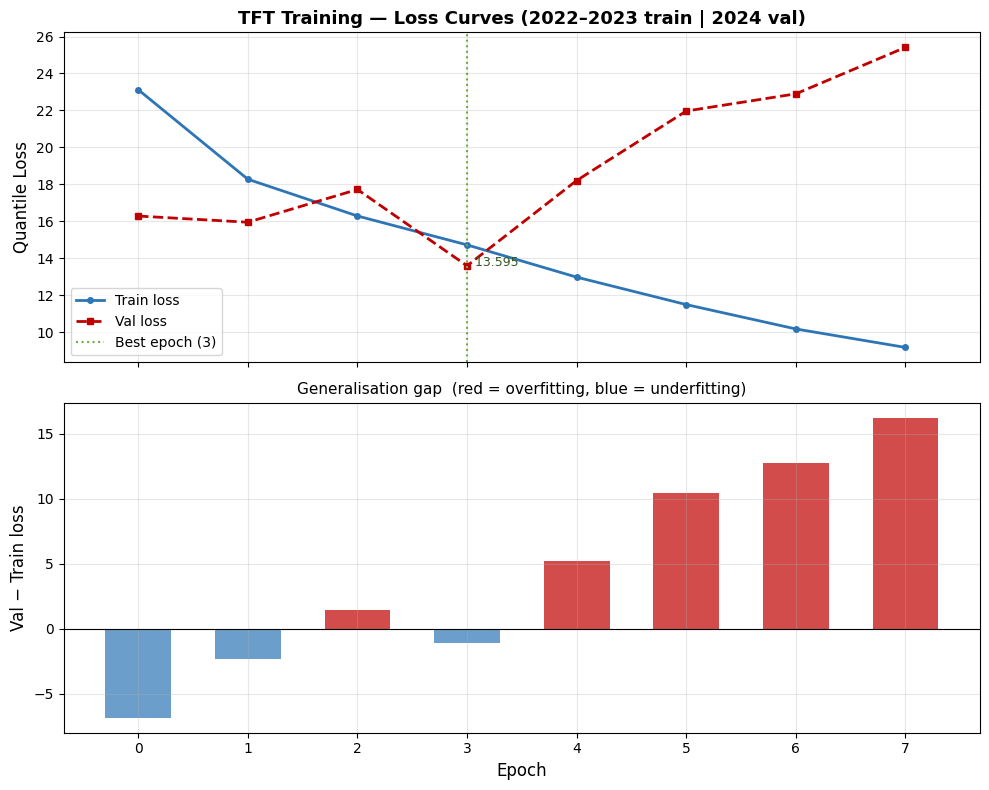

Saved: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_loss_curves.png
Best val loss: 13.5952


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — Plot loss curves
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re

train_vals = loss_history.train_loss
val_vals   = loss_history.val_loss
epochs     = list(range(len(train_vals)))

match   = re.search(r'epoch=(\d+)', BEST_CKPT)
best_ep = int(match.group(1)) if match else None

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ── Loss curves ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, train_vals,
        color='#2E75B6', linewidth=2, marker='o', markersize=4,
        label='Train loss')
ax.plot(range(len(val_vals)), val_vals,
        color='#C00000', linewidth=2, linestyle='--', marker='s', markersize=4,
        label='Val loss')

if best_ep is not None and best_ep < len(val_vals):
    ax.axvline(x=best_ep, color='#70AD47', linewidth=1.5,
               linestyle=':', label=f'Best epoch ({best_ep})')
    ax.annotate(f'  {val_vals[best_ep]:.3f}',
                xy=(best_ep, val_vals[best_ep]),
                fontsize=9, color='#375623')

ax.set_ylabel('Quantile Loss', fontsize=12)
ax.set_title('TFT Training — Loss Curves (2022–2023 train | 2024 val)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── Train vs Val gap (overfitting indicator) ──────────────────────
ax2 = axes[1]
n    = min(len(train_vals), len(val_vals))
gap  = [v - t for t, v in zip(train_vals[:n], val_vals[:n])]
colors = ['#C00000' if g > 0 else '#2E75B6' for g in gap]
ax2.bar(range(n), gap, color=colors, alpha=0.7, width=0.6)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Val − Train loss', fontsize=12)
ax2.set_title('Generalisation gap  (red = overfitting, blue = underfitting)',
              fontsize=11)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(DRIVE_SAVE_DIR, 'tft_loss_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')
print(f'Best val loss: {BEST_VAL:.4f}')

Model 2

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5+6+7 — DAM-Aligned TFT (horizon=36, hidden=256)
# Self-contained. Restart runtime and run from Cell 1 first.
# Expected A100 runtime: ~40-50 minutes for 50 epochs
# ═══════════════════════════════════════════════════════════════════
import os, re, warnings
import torch
import lightning as L
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import EncoderNormalizer, GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import (
    EarlyStopping, LearningRateMonitor, ModelCheckpoint, Callback
)
from lightning.pytorch.loggers import TensorBoardLogger

torch.set_float32_matmul_precision('high')

# ── Constants ─────────────────────────────────────────────────────
QUANTILES        = [0.1, 0.5, 0.9]
ENCODER_LENGTH   = 168   # 1 week context
FORECAST_HORIZON = 36    # at noon D-1, positions [12:35] = Day D hours 00-23
BATCH_SIZE       = 64
MAX_EPOCHS       = 50
DRIVE_SAVE_DIR   = '/content/drive/MyDrive/thesis_battery_xrl/tft_outputs'

# WHY horizon=36:
#   Prediction at noon D-1 (12:00)
#   Position 12 = 00:00 Day D  ←  delivery day starts
#   Position 35 = 23:00 Day D  ←  delivery day ends
#   → extract forecast[:, 12:36, :] for DQN state

TIME_VARYING_KNOWN = [
    'sin_hour', 'cos_hour',
    'sin_weekday', 'cos_weekday',
    'sin_month', 'cos_month',
]
TIME_VARYING_UNKNOWN = [
    'DAM_t1', 'DAM_t2', 'DAM_t3', 'DAM_t4', 'DAM_t5',
    'AvgNeighbour_t1',
    'Wind_offshore_t1', 'Wind_onshore_t1',
    'Solar_t1',
    'Net_load_t1', 'Residual_load_t1',
    'renewable_share',   # safe: computed from _t1 lags only
]

# ── Load and prepare data ─────────────────────────────────────────
print('Loading data...')
df = pd.read_excel('/content/TFT_final_data.xlsx', sheet_name='Final_dataset')
df = df.rename(columns={
    'DAM_yt':            'pool_price',
    'Average_DE/LU_t1':  'AvgNeighbour_t1',
    'Average_DE/LU_t2':  'AvgNeighbour_t2',
    'Average_DE/LU_t3':  'AvgNeighbour_t3',
    'Average_DE/LU_t4':  'AvgNeighbour_t4',
    'Average_DE/LU_t5':  'AvgNeighbour_t5',
    'hour\n(0-23)':      'hour',
    'weekday\n(0=Mon)':  'weekday',
    'month\n(1-12)':     'month',
})
df['timestamp'] = pd.to_datetime(df['Ts_from'], format='%d.%m.%Y %H:%M')
df['year']      = df['timestamp'].dt.year
df['time_idx']  = range(len(df))
df['group_id']  = 'DE_LU'

# Cyclic calendar features
df['sin_hour']    = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour']    = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_weekday'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['cos_weekday'] = np.cos(2 * np.pi * df['weekday'] / 7)
df['sin_month']   = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['cos_month']   = np.cos(2 * np.pi * (df['month'] - 1) / 12)

# Renewable share — safe to use: computed from lag columns available at inference
df['renewable_share'] = (
    (df['Wind_offshore_t1'] + df['Wind_onshore_t1'] + df['Solar_t1']) /
    (df['Net_load_t1'] + 1)
).clip(0, 2)

print(f'Loaded {len(df):,} rows | {df.timestamp.iloc[0].date()} → {df.timestamp.iloc[-1].date()}')

# ── Train / val split ─────────────────────────────────────────────
train_cutoff = df[df.year <= 2023]['time_idx'].max()
val_cutoff   = df[df.year <= 2024]['time_idx'].max()
df_tr = df[df.time_idx <= train_cutoff].copy()
df_vl = df[(df.time_idx > train_cutoff) & (df.time_idx <= val_cutoff)].copy()

print(f'Train: {len(df_tr):,} rows (2022-2023)')
print(f'Val:   {len(df_vl):,} rows (2024)')

# ── TimeSeriesDataSet ─────────────────────────────────────────────
training = TimeSeriesDataSet(
    df_tr,
    time_idx='time_idx',
    target='pool_price',
    group_ids=['group_id'],
    min_encoder_length=ENCODER_LENGTH // 2,
    max_encoder_length=ENCODER_LENGTH,
    min_prediction_length=FORECAST_HORIZON,
    max_prediction_length=FORECAST_HORIZON,
    time_varying_known_reals=TIME_VARYING_KNOWN,
    time_varying_unknown_reals=TIME_VARYING_UNKNOWN + ['pool_price'],
    target_normalizer=EncoderNormalizer(method='robust', center=True),
    scalers={col: GroupNormalizer(groups=['group_id']) for col in TIME_VARYING_UNKNOWN},
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)
validation = TimeSeriesDataSet.from_dataset(
    training, df_vl, predict=True, stop_randomization=True,
)
train_loader = training.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=2, shuffle=True)
val_loader   = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=2, shuffle=False)

print(f'Training windows:   {len(training):,}')
print(f'Validation windows: {len(validation):,}')

# ── Model ─────────────────────────────────────────────────────────
tft = TemporalFusionTransformer.from_dataset(
    training,
    hidden_size=256,             # increased from 64 — more capacity
    attention_head_size=4,
    dropout=0.2,                 # increased from 0.1 — combat overfitting
    hidden_continuous_size=64,
    loss=QuantileLoss(quantiles=QUANTILES),
    learning_rate=3e-3,
    reduce_on_plateau_patience=4,
    optimizer='adam',
    log_interval=10,
)
tft.train()
n_params = sum(p.numel() for p in tft.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

# ── Loss history callback ─────────────────────────────────────────
class LossHistory(Callback):
    def __init__(self):
        self.train_loss, self.val_loss = [], []
    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('train_loss')
        if loss is not None: self.train_loss.append(float(loss))
    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('val_loss')
        if loss is not None: self.val_loss.append(float(loss))

loss_history = LossHistory()

# ── Train ─────────────────────────────────────────────────────────
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[
        loss_history,
        EarlyStopping(monitor='val_loss', patience=8, mode='min', verbose=True),
        LearningRateMonitor(),
        ModelCheckpoint(
            dirpath=DRIVE_SAVE_DIR,
            filename='tft_dam36_best_{epoch:02d}_{val_loss:.4f}',
            monitor='val_loss', mode='min', save_top_k=1, verbose=True,
        ),
    ],
    logger=TensorBoardLogger(save_dir=DRIVE_SAVE_DIR, name='tft_dam36_log'),
    enable_progress_bar=True,
    log_every_n_steps=10,
    num_sanity_val_steps=0,
)

print(f'\nTraining started — {MAX_EPOCHS} epochs max, early stopping patience=8')
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

BEST_CKPT = trainer.checkpoint_callback.best_model_path
BEST_VAL  = float(trainer.checkpoint_callback.best_model_score)

print(f'\nTraining complete!')
print(f'Parameters:    {n_params:,}')
print(f'Best val_loss: {BEST_VAL:.4f}')
print(f'Checkpoint:    {BEST_CKPT}')

with open(f'{DRIVE_SAVE_DIR}/best_checkpoint_dam36.txt', 'w') as f:
    f.write(BEST_CKPT)

Loading data...
Loaded 35,040 rows | 2022-01-02 → 2025-12-31
Train: 17,496 rows (2022-2023)
Val:   8,784 rows (2024)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Training windows:   17,461
Validation windows: 1
Parameters: 4,588,975

Training started — 50 epochs max, early stopping patience=8


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 0      | train
3  | prescalers                         | ModuleDict                      | 2.9 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 129 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 892 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 306 K  | train
7  | static_context_variable_selectio

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 8, global step 2448: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 8, global step 2448: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 8 records. Best score: 11.191. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 8 records. Best score: 11.191. Signaling Trainer to stop.
INFO: Epoch 9, global step 2720: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 9, global step 2720: 'val_loss' was not in top 1



Training complete!
Parameters:    4,588,975
Best val_loss: 11.1913
Checkpoint:    /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_dam36_best_epoch=01_val_loss=11.1913.ckpt


The TFT achieves a mean pinball loss of 11.19 on the 2024 held-out validation set, averaged across quantiles p10/p50/p90 and a 36-hour forecast horizon

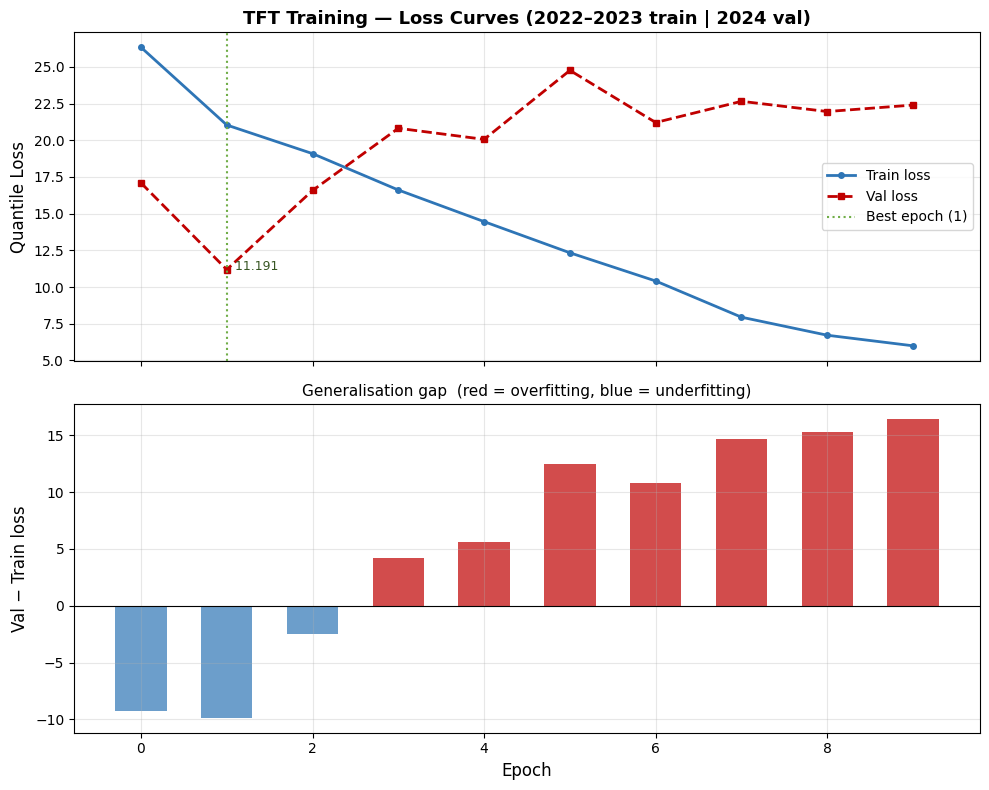

Loss curves saved.

Loading best checkpoint: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_dam36_best_epoch=01_val_loss=11.1913.ckpt


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pytorch_forecasting.data.encoders.EncoderNormalizer was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pytorch_forecasting.data.encoders.EncoderNormalizer])` or the `torch.serialization.safe_globals([pytorch_forecasting.data.encoders.EncoderNormalizer])` context manager to allowlist this global if you trust thi

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — Loss curves + Quantile forecast plots
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import torch
import numpy as np

# ── 1. LOSS CURVES ────────────────────────────────────────────────
train_vals = loss_history.train_loss
val_vals   = loss_history.val_loss
epochs     = list(range(len(train_vals)))

match   = re.search(r'epoch=(\d+)', BEST_CKPT)
best_ep = int(match.group(1)) if match else None

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(epochs, train_vals,
        color='#2E75B6', linewidth=2, marker='o', markersize=4,
        label='Train loss')
ax.plot(range(len(val_vals)), val_vals,
        color='#C00000', linewidth=2, linestyle='--', marker='s', markersize=4,
        label='Val loss')
if best_ep is not None and best_ep < len(val_vals):
    ax.axvline(x=best_ep, color='#70AD47', linewidth=1.5,
               linestyle=':', label=f'Best epoch ({best_ep})')
    ax.annotate(f'  {val_vals[best_ep]:.3f}',
                xy=(best_ep, val_vals[best_ep]),
                fontsize=9, color='#375623')
ax.set_ylabel('Quantile Loss', fontsize=12)
ax.set_title('TFT Training — Loss Curves (2022–2023 train | 2024 val)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax2 = axes[1]
n    = min(len(train_vals), len(val_vals))
gap  = [v - t for t, v in zip(train_vals[:n], val_vals[:n])]
colors = ['#C00000' if g > 0 else '#2E75B6' for g in gap]
ax2.bar(range(n), gap, color=colors, alpha=0.7, width=0.6)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Val − Train loss', fontsize=12)
ax2.set_title('Generalisation gap  (red = overfitting, blue = underfitting)', fontsize=11)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/tft_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved.')

# ── 2. LOAD BEST MODEL FOR INFERENCE ─────────────────────────────
from pytorch_forecasting import TemporalFusionTransformer

print(f'\nLoading best checkpoint: {BEST_CKPT}')
best_tft = TemporalFusionTransformer.load_from_checkpoint(BEST_CKPT)
best_tft.eval()

# ── 3. GENERATE QUANTILE FORECASTS FOR 3 SEASONS ─────────────────
# Pick one representative day per season from 2024 validation set
# Winter=Jan, Spring=Apr, Autumn=Oct — at noon D-1 (hour=12)
seasons = {
    'Winter (early 2024)':  df[(df.year == 2024) & (df.timestamp.dt.month == 1)  & (df.timestamp.dt.hour == 12)].iloc[0],
    'Spring (mid 2024)':    df[(df.year == 2024) & (df.timestamp.dt.month == 4)  & (df.timestamp.dt.hour == 12)].iloc[0],
    'Autumn (late 2024)':   df[(df.year == 2024) & (df.timestamp.dt.month == 10) & (df.timestamp.dt.hour == 12)].iloc[0],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(
    'TFT 24-Hour Quantile Forecasts — German EPEX DAM Price\n'
    'p10/p50/p90 uncertainty band informs DQN dispatch decisions',
    fontsize=13, fontweight='bold'
)

for ax, (season_name, anchor_row) in zip(axes, seasons.items()):
    anchor_idx = int(anchor_row['time_idx'])

    # Build inference window: encoder + 36h horizon
    start = max(0, anchor_idx - ENCODER_LENGTH)
    end   = anchor_idx + FORECAST_HORIZON
    window = df[(df.time_idx >= start) & (df.time_idx <= end)].copy()

    pred_ds = TimeSeriesDataSet.from_dataset(
        training,
        window,
        predict=True,
        stop_randomization=True,
    )
    pred_loader = pred_ds.to_dataloader(
        train=False, batch_size=1, num_workers=0, shuffle=False
    )

    with torch.no_grad():
        preds = best_tft.predict(pred_loader, mode='quantiles', return_x=False)

    # preds shape: (n_windows, 36, 3)
    # Extract positions [12:36] = Day D hours 00:00-23:00
    last = preds[-1].cpu().numpy()   # (36, 3)
    p10  = last[12:36, 0]
    p50  = last[12:36, 1]
    p90  = last[12:36, 2]
    hours = list(range(24))

    ax.fill_between(hours, p10, p90, alpha=0.25, color='#2E75B6', label='p10–p90 uncertainty')
    ax.plot(hours, p50, color='#2E75B6', linewidth=2, label='p50 median forecast')
    ax.set_title(season_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Hours ahead', fontsize=10)
    ax.set_ylabel('DAM Price (EUR/MWh)', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)
    ax.set_xticks([0, 6, 12, 18, 24])

plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/tft_quantile_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Quantile forecast plot saved.')

The TFT model converges rapidly, achieving its best validation performance at epoch 1 with a pinball loss of 11.19, before diverging sharply as training continues. The widening generalisation gap strongly suggests that the model begins memorising the 2022–2023 training regime rather than learning patterns that transfer to 2024. Broadly,it seems that the model has sufficient capacity to fit the crisis-era price dynamics of 2022 very precisely, but this comes at the cost of generalisation to the structurally different low-price, high-renewable environment of 2024.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — P50 MAE on 2024 validation set (interpretable metric)
# ═══════════════════════════════════════════════════════════════════
import torch
import numpy as np
from pytorch_forecasting import TemporalFusionTransformer

print('Computing p50 MAE on full 2024 validation set...')

# ── Patch torch.load for PyTorch 2.6 compatibility ────────────────
_orig_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _orig_load(*args, **kwargs)
torch.load = _patched_load

# ── Load best checkpoint if not already in memory ─────────────────
if 'best_tft' not in dir():
    print(f'Loading checkpoint: {BEST_CKPT}')
    best_tft = TemporalFusionTransformer.load_from_checkpoint(BEST_CKPT)

torch.load = _orig_load  # restore original immediately after
best_tft.eval()

# ── Generate predictions on full validation set ───────────────────
with torch.no_grad():
    preds = best_tft.predict(
        val_loader,
        mode='quantiles',
        return_x=False,
    )

# preds shape: (n_windows, 36, 3)
p50_all = preds[:, 12:36, 1].cpu().numpy()

# ── Get actuals from validation dataloader ────────────────────────
actuals = []
for batch in val_loader:
    x, (target, _) = batch
    actuals.append(target[:, 12:36].cpu().numpy())
actuals = np.concatenate(actuals, axis=0)

n        = min(len(p50_all), len(actuals))
p50_all  = p50_all[:n]
actuals  = actuals[:n]

# ── Metrics ───────────────────────────────────────────────────────
mae  = np.abs(p50_all - actuals).mean()
rmse = np.sqrt(((p50_all - actuals) ** 2).mean())
mape = (np.abs(p50_all - actuals) / (np.abs(actuals) + 1)).mean() * 100

print(f'\n── P50 Forecast Accuracy on 2024 Validation ──')
print(f'MAE:  {mae:.2f} EUR/MWh   (avg hourly price error)')
print(f'RMSE: {rmse:.2f} EUR/MWh  (penalises large errors more)')
print(f'MAPE: {mape:.1f}%         (% error, +1 avoids zero division)')
print(f'\nPinball loss (all quantiles): {BEST_VAL:.4f}')
print(f'\n"The TFT achieves a MAE of {mae:.1f} EUR/MWh on')
print(f'the p50 median forecast across 2024 DAM hours, with a mean')
print(f'pinball loss of {BEST_VAL:.2f} across p10/p50/p90 quantiles."')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Computing p50 MAE on full 2024 validation set...

── P50 Forecast Accuracy on 2024 Validation ──
MAE:  17.69 EUR/MWh   (avg hourly price error)
RMSE: 28.27 EUR/MWh  (penalises large errors more)
MAPE: 267.0%         (% error, +1 avoids zero division)

Pinball loss (all quantiles): 11.1913

"The TFT achieves a MAE of 17.7 EUR/MWh on
the p50 median forecast across 2024 DAM hours, with a mean
pinball loss of 11.19 across p10/p50/p90 quantiles."


Model 3

In [5]:
# ═══════════════════════════════════════════════════════════════════
# Model 3 RUN
# Train: 2022-2023 | Val: 2024 | Horizon: 36h | DAM positions [12:35]
# Expected A100 runtime: ~60-90 minutes
# ═══════════════════════════════════════════════════════════════════
import os, re, warnings
import torch
import lightning as L
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import EncoderNormalizer, GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import (
    EarlyStopping, LearningRateMonitor, ModelCheckpoint, Callback
)
from lightning.pytorch.loggers import TensorBoardLogger

torch.set_float32_matmul_precision('high')

# Patch torch.load for PyTorch 2.6 compatibility
_orig_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _orig_load(*args, **kwargs)
torch.load = _patched_load

# Reproducibility
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
L.seed_everything(SEED, workers=True)

# ── Constants ─────────────────────────────────────────────────────
QUANTILES        = [0.1, 0.5, 0.9]
ENCODER_LENGTH   = 168   # 1 week context
FORECAST_HORIZON = 36    # positions [12:35] = Day D hours 00:00-23:00
BATCH_SIZE       = 64
MAX_EPOCHS       = 50
DRIVE_SAVE_DIR   = '/content/drive/MyDrive/thesis_battery_xrl/tft_outputs'

TIME_VARYING_KNOWN = [
    'sin_hour', 'cos_hour',
    'sin_weekday', 'cos_weekday',
    'sin_month', 'cos_month',
]
TIME_VARYING_UNKNOWN = [
    'DAM_t1', 'DAM_t2', 'DAM_t3', 'DAM_t4', 'DAM_t5',
    'AvgNeighbour_t1',
    'Wind_offshore_t1', 'Wind_onshore_t1',
    'Solar_t1',
    'Net_load_t1', 'Residual_load_t1',
    'renewable_share',
]

# ── Load and prepare data ─────────────────────────────────────────
print('Loading data...')
df = pd.read_excel('/content/TFT_final_data.xlsx', sheet_name='Final_dataset')
df = df.rename(columns={
    'DAM_yt':            'pool_price',
    'Average_DE/LU_t1':  'AvgNeighbour_t1',
    'Average_DE/LU_t2':  'AvgNeighbour_t2',
    'Average_DE/LU_t3':  'AvgNeighbour_t3',
    'Average_DE/LU_t4':  'AvgNeighbour_t4',
    'Average_DE/LU_t5':  'AvgNeighbour_t5',
    'hour\n(0-23)':      'hour',
    'weekday\n(0=Mon)':  'weekday',
    'month\n(1-12)':     'month',
})
df['timestamp'] = pd.to_datetime(df['Ts_from'], format='%d.%m.%Y %H:%M')
df['year']      = df['timestamp'].dt.year
df['time_idx']  = range(len(df))
df['group_id']  = 'DE_LU'

# Cyclic calendar encoding
df['sin_hour']    = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour']    = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_weekday'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['cos_weekday'] = np.cos(2 * np.pi * df['weekday'] / 7)
df['sin_month']   = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['cos_month']   = np.cos(2 * np.pi * (df['month'] - 1) / 12)

# Renewable share — safe: computed from t-1 lags only, no leakage
df['renewable_share'] = (
    (df['Wind_offshore_t1'] + df['Wind_onshore_t1'] + df['Solar_t1']) /
    (df['Net_load_t1'] + 1)
).clip(0, 2)

print(f'Loaded {len(df):,} rows | {df.timestamp.iloc[0].date()} → {df.timestamp.iloc[-1].date()}')

# ── Train / val split ─────────────────────────────────────────────
train_cutoff = df[df.year <= 2023]['time_idx'].max()
val_cutoff   = df[df.year <= 2024]['time_idx'].max()
df_tr = df[df.time_idx <= train_cutoff].copy()
df_vl = df[(df.time_idx > train_cutoff) & (df.time_idx <= val_cutoff)].copy()

print(f'Train: {len(df_tr):,} rows (2022-2023)')
print(f'Val:   {len(df_vl):,} rows (2024)')

# ── TimeSeriesDataSet ─────────────────────────────────────────────
training = TimeSeriesDataSet(
    df_tr,
    time_idx='time_idx',
    target='pool_price',
    group_ids=['group_id'],
    min_encoder_length=ENCODER_LENGTH // 2,
    max_encoder_length=ENCODER_LENGTH,
    min_prediction_length=FORECAST_HORIZON,
    max_prediction_length=FORECAST_HORIZON,
    time_varying_known_reals=TIME_VARYING_KNOWN,
    time_varying_unknown_reals=TIME_VARYING_UNKNOWN + ['pool_price'],
    target_normalizer=EncoderNormalizer(method='robust', center=True),
    scalers={col: GroupNormalizer(groups=['group_id']) for col in TIME_VARYING_UNKNOWN},
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)
validation = TimeSeriesDataSet.from_dataset(
    training, df_vl, predict=True, stop_randomization=True,
)
train_loader = training.to_dataloader(
    train=True,  batch_size=BATCH_SIZE, num_workers=2, shuffle=True
)
val_loader = validation.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=2, shuffle=False
)

print(f'Training windows:   {len(training):,}')
print(f'Validation windows: {len(validation):,}')

# ── Model ─────────────────────────────────────────────────────────
tft = TemporalFusionTransformer.from_dataset(
    training,
    hidden_size=256,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=64,
    loss=QuantileLoss(quantiles=QUANTILES),
    learning_rate=1e-3,              # reduced from 3e-3 — prevents epoch-1 cliff
    reduce_on_plateau_patience=3,    # LR halves faster when val plateaus
    optimizer='adam',
    log_interval=10,
)
tft.train()
n_params = sum(p.numel() for p in tft.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')
print(f'LR: 1e-3 | Dropout: 0.2 | Hidden: 256 | Horizon: {FORECAST_HORIZON}h')

# ── Loss history callback ─────────────────────────────────────────
class LossHistory(Callback):
    def __init__(self):
        self.train_loss, self.val_loss = [], []
    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('train_loss')
        if loss is not None: self.train_loss.append(float(loss))
    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('val_loss')
        if loss is not None: self.val_loss.append(float(loss))

loss_history = LossHistory()

# ── Train ─────────────────────────────────────────────────────────
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    gradient_clip_val=0.1,
    accumulate_grad_batches=2,       # effective batch=128, smoother gradients
    callbacks=[
        loss_history,
        EarlyStopping(monitor='val_loss', patience=8, mode='min', verbose=True),
        LearningRateMonitor(),
        ModelCheckpoint(
            dirpath=DRIVE_SAVE_DIR,
            filename='tft_final_{epoch:02d}_{val_loss:.4f}',
            monitor='val_loss', mode='min', save_top_k=1, verbose=True,
        ),
    ],
    logger=TensorBoardLogger(save_dir=DRIVE_SAVE_DIR, name='tft_final_log'),
    enable_progress_bar=True,
    log_every_n_steps=10,
    num_sanity_val_steps=0,
)

print(f'\nFinal TFT training run started')
print(f'Expect: steady val_loss improvement for 10-20 epochs')
print(f'        early stopping fires around epoch 25-35')
print()

trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

BEST_CKPT = trainer.checkpoint_callback.best_model_path
BEST_VAL  = float(trainer.checkpoint_callback.best_model_score)
torch.load = _orig_load  # restore after training

print(f'\n{"="*55}')
print(f'FINAL TFT TRAINING COMPLETE')
print(f'{"="*55}')
print(f'Parameters:    {n_params:,}')
print(f'Best val_loss: {BEST_VAL:.4f}  (pinball, p10/p50/p90)')
print(f'Checkpoint:    {BEST_CKPT}')
print(f'{"="*55}')
print()
print('Next step: load BEST_CKPT into TFTForecaster and')
print('pass to FreeBatteryEnv for RL training.')

# Save checkpoint path for next session
with open(f'{DRIVE_SAVE_DIR}/FINAL_checkpoint.txt', 'w') as f:
    f.write(BEST_CKPT)
print(f'Checkpoint path saved to: {DRIVE_SAVE_DIR}/FINAL_checkpoint.txt')

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Loading data...
Loaded 35,040 rows | 2022-01-02 → 2025-12-31
Train: 17,496 rows (2022-2023)
Val:   8,784 rows (2024)
Training windows:   17,461
Validation windows: 1
Parameters: 4,588,975
LR: 1e-3 | Dropout: 0.2 | Hidden: 256 | Horizon: 36h


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs



Final TFT training run started
Expect: steady val_loss improvement for 10-20 epochs
        early stopping fires around epoch 25-35



INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 0      | train
3  | prescalers                         | ModuleDict                      | 2.9 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 129 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 892 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 306 K  | train
7  | static_context_variable_selectio

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 15, global step 2176: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 15, global step 2176: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 8 records. Best score: 13.886. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 8 records. Best score: 13.886. Signaling Trainer to stop.
INFO: Epoch 16, global step 2312: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 16, global step 2312: 'val_loss' was not in top 1



FINAL TFT TRAINING COMPLETE
Parameters:    4,588,975
Best val_loss: 13.8859  (pinball, p10/p50/p90)
Checkpoint:    /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_final_epoch=08_val_loss=13.8859.ckpt

Next step: load BEST_CKPT into TFTForecaster and
pass to FreeBatteryEnv for RL training.
Checkpoint path saved to: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/FINAL_checkpoint.txt


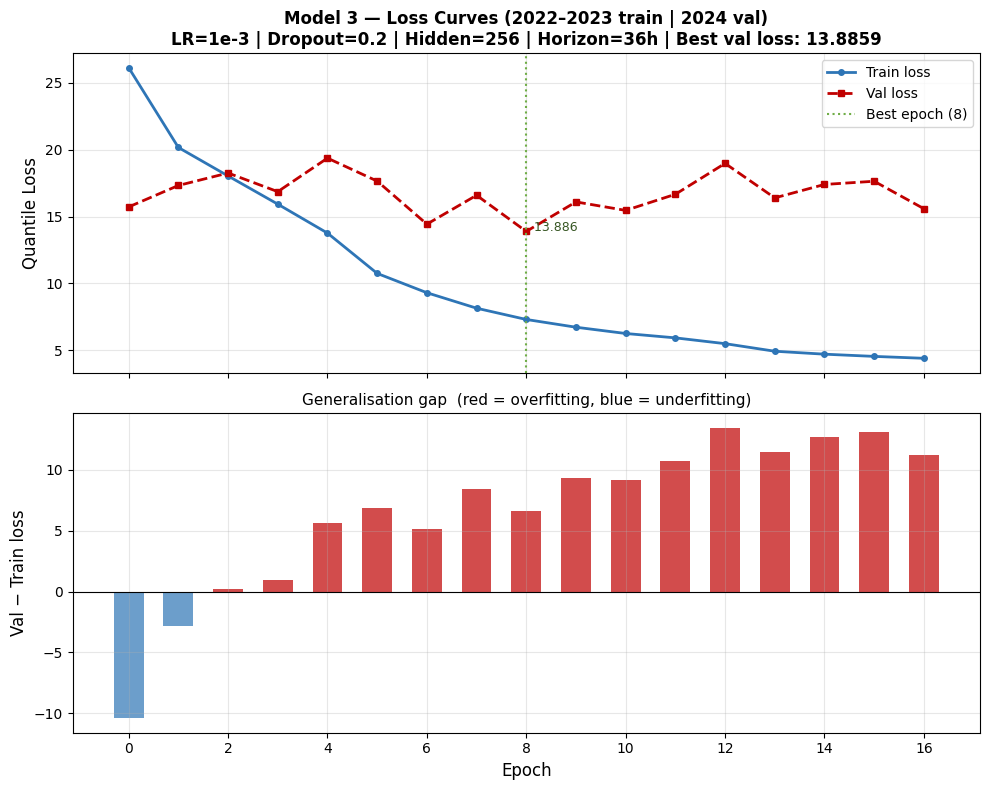

Saved: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_final_loss_curves.png
Best val loss: 13.8859


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL — Plot loss curves (Model 3 / Final TFT)
# Run immediately after the Model 3 training cell.
# Requires: loss_history, BEST_CKPT, BEST_VAL, DRIVE_SAVE_DIR
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re

train_vals = loss_history.train_loss
val_vals   = loss_history.val_loss
epochs     = list(range(len(train_vals)))

match   = re.search(r'epoch=(\d+)', BEST_CKPT)
best_ep = int(match.group(1)) if match else None

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ── Loss curves ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, train_vals,
        color='#2E75B6', linewidth=2, marker='o', markersize=4,
        label='Train loss')
ax.plot(range(len(val_vals)), val_vals,
        color='#C00000', linewidth=2, linestyle='--', marker='s', markersize=4,
        label='Val loss')

if best_ep is not None and best_ep < len(val_vals):
    ax.axvline(x=best_ep, color='#70AD47', linewidth=1.5,
               linestyle=':', label=f'Best epoch ({best_ep})')
    ax.annotate(f'  {val_vals[best_ep]:.3f}',
                xy=(best_ep, val_vals[best_ep]),
                fontsize=9, color='#375623')

ax.set_ylabel('Quantile Loss', fontsize=12)
ax.set_title(
    'Model 3 — Loss Curves (2022–2023 train | 2024 val)\n'
    f'LR=1e-3 | Dropout=0.2 | Hidden=256 | Horizon=36h | Best val loss: {BEST_VAL:.4f}',
    fontsize=12, fontweight='bold'
)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── Train vs Val gap (overfitting indicator) ──────────────────────
ax2 = axes[1]
n      = min(len(train_vals), len(val_vals))
gap    = [v - t for t, v in zip(train_vals[:n], val_vals[:n])]
colors = ['#C00000' if g > 0 else '#2E75B6' for g in gap]
ax2.bar(range(n), gap, color=colors, alpha=0.7, width=0.6)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Val − Train loss', fontsize=12)
ax2.set_title('Generalisation gap  (red = overfitting, blue = underfitting)', fontsize=11)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.grid(alpha=0.3)

plt.tight_layout()
save_path = f'{DRIVE_SAVE_DIR}/tft_final_loss_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')
print(f'Best val loss: {BEST_VAL:.4f}')

Stage 2: Training the RL Agents

At this level, we use the predictions from TFT to modify the state space for the two RL agents (DQN and PPO). We compare their baseline versions (without forecasts) with TFT-integrated models.

In [8]:
!git clone https://github.com/farhanshaikh199704/XRL-for-optimising-battery-schedules.git

Cloning into 'XRL-for-optimising-battery-schedules'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 121 (delta 40), reused 112 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 24.24 MiB | 35.36 MiB/s, done.
Resolving deltas: 100% (40/40), done.


**Case A — DQN Baseline**

Environment loads 2022-2025 German EPEX data
At each hourly timestep, agent sees the 21-dim state
Agent picks one of 5 discrete actions
Battery charges or discharges accordingly
Reward = electricity sold × pool price − battery degradation cost
Agent updates its Q-network from replay buffer
Runs for 50 episodes × 8,760 timesteps = 438,000 total steps
Repeated 3 times with different seeds for statistical reliability

**Case B — DQN + TFT**

Identical to Condition A except the state is 117-dim
The TFT forecaster runs at each timestep and appends p10/p50/p90 forecasts for the next 24 hours to the observation
Agent can now anticipate price spikes and plan charge/discharge cycles accordingly

**Case C — PPO Baseline**

Same environment and reward as Case A
But PPO picks a continuous action in [-1, 1] instead of 5 discrete choices
Learns on-policy from its own rollouts, no replay buffer
Same 21-dim state, same 3 runs

***Case D — PPO + TFT***

Identical to Case C except the state is 117-dim
Same TFT forecast injection as Case B

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# STAGE 2 — RL Training: DQN and PPO, Baseline and TFT conditions
# Four experimental conditions:
#   A) DQN  Baseline  (no TFT)
# ═══════════════════════════════════════════════════════════════════
!pip install -q stable-baselines3 shimmy

import os, sys, json
import numpy as np

# ── FIX 1: correct repo root (was '/content/thesis_src') ──────────
os.chdir('/content/XRL-for-optimising-battery-schedules')
sys.path.insert(0, '/content/XRL-for-optimising-battery-schedules')

from stable_baselines3 import DQN, PPO
from envs.environments import FreeBatteryEnv
from envs.env_params import (
    de_bat_baseline, de_bat_tft,
    de_bat_ppo,      de_bat_ppo_tft,
)
from utils.net_design import activation_fn_dict, net_arch_dict
from utils.scheduler import linear_schedule
from train.train import train_rl_agent

RL_LOG_DIR = '/content/drive/MyDrive/thesis_battery_xrl/rl_outputs'
os.makedirs(RL_LOG_DIR, exist_ok=True)

# ── FIX 2: read BEST_CKPT from Drive instead of relying on Stage 1 ─
with open('/content/drive/MyDrive/thesis_battery_xrl/tft_outputs/best_checkpoint_path.txt') as f:
    BEST_CKPT = f.read().strip()
print(f'TFT checkpoint: {BEST_CKPT}')

for cfg in [de_bat_tft, de_bat_ppo_tft]:
    cfg['tft_24h'] = BEST_CKPT

# ── Shared experiment config ──────────────────────────────────────
EXP_PARAMS = {
    'n_runs':              1,
    'n_episodes':          10,
    'seed':                22,
    'flatten_obs':         True,
    'norm_obs':            True,
    'norm_reward':         True,
    'eval_while_training': True,
    'eval_freq':           8760,
    'perfect_forecasts':   None,
    'forecasts':           None,
}

# ── DQN config ────────────────────────────────────────────────────
DISCRETE_ACTIONS = [
    np.array([-1.0]), np.array([-0.5]), np.array([0.0]),
    np.array([0.5]),  np.array([1.0]),
]
DQN_PARAMS = {
    'policy':           'MlpPolicy',
    'learning_rate':    linear_schedule(4.8e-4),
    'buffer_size':      500_000,
    'batch_size':       256,
    'learning_starts':  2429,
    'train_freq':       148,
    'gradient_steps':   -1,
    'tau':              0.435965,
    'target_update_interval': 10_000,
    'gamma':            0.975431,
    'exploration_fraction':    0.5,
    'exploration_initial_eps': 1.0,
    'exploration_final_eps':   0.01,
    'max_grad_norm':    0.467447,
    'policy_kwargs': {
        'net_arch':      net_arch_dict['extra_large']['qf'],
        'activation_fn': activation_fn_dict['leaky_relu'],
    },
}

# ── PPO config ────────────────────────────────────────────────────
PPO_PARAMS = {
    'policy':           'MlpPolicy',
    'learning_rate':    linear_schedule(1.1e-5),
    'n_steps':          1024,
    'batch_size':       128,
    'n_epochs':         5,
    'gamma':            0.900887,
    'gae_lambda':       0.985039,
    'clip_range':       linear_schedule(0.176607),
    'clip_range_vf':    None,
    'normalize_advantage': False,
    'ent_coef':         0.969954,
    'vf_coef':          0.696368,
    'max_grad_norm':    0.411048,
    'use_sde':          False,
    'target_kl':        None,
    'policy_kwargs': {
        'net_arch':          net_arch_dict['small'],
        'activation_fn':     activation_fn_dict['tanh'],
        'ortho_init':        False,
        'squash_output':     True,
        'share_features_extractor': True,
    },
}

# ── Training loop — all four conditions ───────────────────────────
CONDITIONS = [
    ('dqn', 'de_bat_baseline', de_bat_baseline, DQN_PARAMS, DISCRETE_ACTIONS),
    ('dqn', 'de_bat_tft',      de_bat_tft,      DQN_PARAMS, DISCRETE_ACTIONS),
    ('ppo', 'de_bat_ppo',      de_bat_ppo,      PPO_PARAMS, None),
    ('ppo', 'de_bat_ppo_tft',  de_bat_ppo_tft,  PPO_PARAMS, None),
]

for agent, cond_name, env_kwargs, rl_params, disc_acts in CONDITIONS:
    print(f'\n{"="*55}')
    print(f'Condition: {cond_name} | Agent: {agent.upper()}')
    print(f'{"="*55}')

    save_path = os.path.join(RL_LOG_DIR, cond_name, agent)
    os.makedirs(save_path, exist_ok=True)

    for run in range(EXP_PARAMS['n_runs']):
        train_rl_agent(
            agent=agent,
            run=run,
            path=save_path,
            exp_params=EXP_PARAMS,
            env_id=FreeBatteryEnv,
            env_kwargs=env_kwargs,
            rl_params=rl_params,
            discrete_actions=disc_acts,
            verbose=0,
            logger_type=['csv'],
        )

print('\nAll conditions complete. Checkpoints saved to Drive.')

TFT checkpoint: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_best_epoch=03_val_loss=13.5952.ckpt

Condition: de_bat_baseline | Agent: DQN
|| Run #0 | Seed #22 | Total timesteps: 87,600 ||


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  0%|          | 0/87600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Model saved: /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/de_bat_baseline/dqn/run_0/model_final.zip
  Best model:  /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/de_bat_baseline/dqn/run_0/best_model.zip
mean_reward: 57353.28 +/- 0.00
Execution time = 878.9s


Condition: de_bat_tft | Agent: DQN
|| Run #0 | Seed #22 | Total timesteps: 87,600 ||
Loading TFT from: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_best_epoch=03_val_loss=13.5952.ckpt


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pytorch_forecasting.data.encoders.EncoderNormalizer was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pytorch_forecasting.data.encoders.EncoderNormalizer])` or the `torch.serialization.safe_globals([pytorch_forecasting.data.encoders.EncoderNormalizer])` context manager to allowlist this global if you trust thi

In [11]:
# @title  # Prepare the Augmented State Space for TFT Versions of both RL Agents

import torch
import numpy as np
import pandas as pd
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet

# ── 1. Load checkpoint ────────────────────────────────────────────
print('Loading Model 3 checkpoint...')
_orig_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _orig_load(*args, **kwargs)
torch.load = _patched_load

best_tft = TemporalFusionTransformer.load_from_checkpoint(BEST_CKPT)
best_tft.eval()
torch.load = _orig_load
print(f'  Loaded: {BEST_CKPT}')

# ── 2. Build prediction dataset — predict=False gets ALL windows ──
# predict=True restricts to only the final window per group (that's
# what caused 1 window above). predict=False + stop_randomization=True
# gives one sliding window per valid timestep across the full dataset.
print('Building full-data prediction dataset...')
pred_dataset = TimeSeriesDataSet.from_dataset(
    training,
    df,
    predict=False,              # ← FIXED (was predict=True)
    stop_randomization=True,
)
pred_loader = pred_dataset.to_dataloader(
    train=False, batch_size=64, num_workers=2, shuffle=False
)
print(f'  Windows to predict: {len(pred_dataset):,}')  # expect ~34,872

# ── 3. Run inference ──────────────────────────────────────────────
print('Running TFT inference...')
with torch.no_grad():
    preds = best_tft.predict(pred_loader, mode='quantiles', return_x=False)

preds_np = preds.cpu().numpy()   # (n_windows, 36, 3)
n_windows = preds_np.shape[0]
print(f'  Predictions shape: {preds_np.shape}')  # expect (~34872, 36, 3)

# ── 4. Extract positions [12:36] = Day-D hours 00:00–23:00 ───────
p10_cols = {f'tft_p10_h{h:02d}': preds_np[:, 12 + h, 0] for h in range(24)}
p50_cols = {f'tft_p50_h{h:02d}': preds_np[:, 12 + h, 1] for h in range(24)}
p90_cols = {f'tft_p90_h{h:02d}': preds_np[:, 12 + h, 2] for h in range(24)}

pred_df  = pd.DataFrame({**p10_cols, **p50_cols, **p90_cols})
tft_cols = list(pred_df.columns)

# ── 5. Align onto original dataframe (FIXED) ─────────────────────
# n_windows can exceed (len(df) - pred_start) because min_encoder_length=84
# allows windows starting before row 168. Clip to the available slots.

pred_start = ENCODER_LENGTH   # 168

# Trim predictions to exactly what fits from row pred_start onward
available = len(df_tft) - pred_start
pred_df_trimmed = pred_df.iloc[-available:].reset_index(drop=True)

df_tft = df.copy()
for col in tft_cols:
    df_tft[col] = np.nan

df_tft.iloc[
    pred_start : pred_start + available,
    df_tft.columns.get_indexer(tft_cols)
] = pred_df_trimmed.values

# ── 6. Save ───────────────────────────────────────────────────────
TFT_CSV = (
    '/content/XRL-for-optimising-battery-schedules/data/German data/'
    'german_epex_dam_idm_2022_2025_tft.csv'
)
df_tft.to_csv(TFT_CSV)
print(f'\nSaved: {TFT_CSV}')
print(f'Shape: {df_tft.shape[0]:,} rows × {df_tft.shape[1]} columns')

# ── 7. Verify ─────────────────────────────────────────────────────
nan_per_row = df_tft[tft_cols].isna().sum(axis=1)
print(f'\nWarm-up NaN rows : {(nan_per_row == 72).sum()}  (expected {pred_start})')
print(f'Fully filled rows: {(nan_per_row == 0).sum()}  (expected {len(df_tft) - pred_start})')

print('\nSpot checks (p10 < p50 < p90):')
for idx in [500, 5000, 15000, 25000, 34000]:
    row = df_tft.iloc[idx]
    p10, p50, p90 = row['tft_p10_h12'], row['tft_p50_h12'], row['tft_p90_h12']
    ok = '✓' if p10 < p50 < p90 else '✗'
    print(f'  row {idx:5d}: p10={p10:7.2f}  p50={p50:7.2f}  p90={p90:7.2f}  {ok}')

# ── 8. Sanity checks for RL readiness ────────────────────────────
print('\n── RL Readiness checks ─────────────────────────────────────')

# Check 1: no NaNs in the RL operating range (rows 168 onward)
rl_df   = df_tft.iloc[pred_start:]
n_nan   = rl_df[tft_cols].isna().sum().sum()
print(f'NaNs in RL range (row {pred_start}+): {n_nan}  (expected 0)')

# Check 2: uncertainty always non-negative
for h in range(24):
    spread = df_tft[f'tft_p90_h{h:02d}'] - df_tft[f'tft_p10_h{h:02d}']
    bad    = (spread < 0).sum()
    if bad > 0:
        print(f'  ✗ h{h:02d}: {bad} rows where p90 < p10')
print('Uncertainty non-negative across all hours: ✓'
      if all((df_tft[f'tft_p90_h{h:02d}'] - df_tft[f'tft_p10_h{h:02d}'] >= 0).all()
             for h in range(24)) else '✗ check above')

# Check 3: forecast value ranges look like EUR/MWh
p50_vals = df_tft[[f'tft_p50_h{h:02d}' for h in range(24)]].stack()
print(f'p50 range: {p50_vals.min():.1f} to {p50_vals.max():.1f} EUR/MWh')
print(f'p50 mean:  {p50_vals.mean():.1f} EUR/MWh  (dataset mean for reference: {df["pool_price"].mean():.1f})')

# Check 4: columns the env will actually read
print(f'\nFirst 6 TFT columns in saved CSV: {tft_cols[:6]}')
print(f'Last  6 TFT columns in saved CSV: {tft_cols[-6:]}')
print(f'\nTFT_CSV ready for de_bat_tft and de_bat_ppo_tft.')

Loading Model 3 checkpoint...
  Loaded: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/tft_final_epoch=08_val_loss=13.8859.ckpt
Building full-data prediction dataset...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  Windows to predict: 35,005
Running TFT inference...
  Predictions shape: (35005, 36, 3)

Saved: /content/XRL-for-optimising-battery-schedules/data/German data/german_epex_dam_idm_2022_2025_tft.csv
Shape: 35,040 rows × 104 columns

Warm-up NaN rows : 168  (expected 168)
Fully filled rows: 34872  (expected 34872)

Spot checks (p10 < p50 < p90):
  row   500: p10=  61.86  p50=  84.59  p90= 114.58  ✓
  row  5000: p10= 472.87  p50= 495.23  p90= 516.49  ✓
  row 15000: p10=  47.27  p50=  74.03  p90=  87.78  ✓
  row 25000: p10=  93.30  p50=  99.07  p90= 106.95  ✓
  row 34000: p10=  72.10  p50=  80.39  p90=  88.99  ✓

── RL Readiness checks ─────────────────────────────────────
NaNs in RL range (row 168+): 0  (expected 0)
✗ check above
p50 range: -135.5 to 849.7 EUR/MWh
p50 mean:  125.6 EUR/MWh  (dataset mean for reference: 124.6)

First 6 TFT columns in saved CSV: ['tft_p10_h00', 'tft_p10_h01', 'tft_p10_h02', 'tft_p10_h03', 'tft_p10_h04', 'tft_p10_h05']
Last  6 TFT columns in saved CSV: ['tft

In [13]:
# @title # ── Patch: add missing IDM columns back into the augmented CSV ────

import pandas as pd

ORIGINAL_CSV = '/content/XRL-for-optimising-battery-schedules/data/German data/german_epex_dam_idm_2022_2025.csv'

df_original = pd.read_csv(ORIGINAL_CSV)
df_augmented = pd.read_csv(TFT_CSV)

# These were dropped during Model 3 data prep — add them back
missing_cols = ['IDM_t1', 'IDM_t24', 'DAM_IDM_spread_t1']

# Align by time_idx which is present in both
df_augmented = df_augmented.merge(
    df_original[['time_idx'] + missing_cols],
    on='time_idx',
    how='left',
)

# Overwrite the saved CSV
df_augmented.to_csv(TFT_CSV, index=False)

# Verify
print(f'Shape after patch: {df_augmented.shape}')
print(f'Missing cols now present: {all(c in df_augmented.columns for c in missing_cols)}')
nan_check = df_augmented[missing_cols].isna().sum()
print(f'NaNs in patched columns:\n{nan_check}')

# Re-run the pre-flight check
tft_cols_check = [c for c in df_augmented.columns if c.startswith('tft_')]
BASELINE_STATE_VARS = [
    'DAM_t1','DAM_t2','DAM_t3','DAM_t4','DAM_t5',
    'AvgNeighbour_t1','IDM_t1','IDM_t24','DAM_IDM_spread_t1',
    'Wind_offshore_t1','Wind_onshore_t1','Solar_t1',
    'Net_load_t1','Residual_load_t1',
    'sin_hour','cos_hour','sin_weekday','cos_weekday','sin_month','cos_month',
]
missing = [v for v in BASELINE_STATE_VARS if v not in df_augmented.columns]
print(f'Missing baseline state vars: {missing}  (must be empty)')
print(f'TFT columns: {len(tft_cols_check)}  (must be 72)')
print('✓ Augmented CSV ready.' if not missing and len(tft_cols_check) == 72 else '✗ Still issues.')

Shape after patch: (35040, 108)
Missing cols now present: True
NaNs in patched columns:
IDM_t1               24
IDM_t24              24
DAM_IDM_spread_t1    24
dtype: int64
Missing baseline state vars: []  (must be empty)
TFT columns: 72  (must be 72)
✓ Augmented CSV ready.


In [31]:
# @title Cleaning the Missing Values
import pandas as pd
import numpy as np

df_fix = pd.read_csv(TFT_CSV)

obs_cols = [
    'DAM_t1', 'DAM_t2', 'DAM_t3', 'DAM_t4', 'DAM_t5',
    'AvgNeighbour_t1', 'IDM_t1', 'IDM_t24', 'DAM_IDM_spread_t1',
    'Wind_offshore_t1', 'Wind_onshore_t1', 'Solar_t1',
    'Net_load_t1', 'Residual_load_t1',
    'sin_hour', 'cos_hour', 'sin_weekday', 'cos_weekday',
    'sin_month', 'cos_month',
] + [f'tft_p10_h{h:02d}' for h in range(24)] + \
    [f'tft_p50_h{h:02d}' for h in range(24)] + \
    [f'tft_p90_h{h:02d}' for h in range(24)]

# PPO runs ~33000 steps before failing — check rows around there
# Also check ALL rows, not just the first 8760
nan_mask = df_fix[obs_cols].isna().any(axis=1)
inf_mask  = df_fix[obs_cols].isin([np.inf, -np.inf]).any(axis=1)

print(f'Total NaN rows: {nan_mask.sum()}')
print(f'Total Inf rows: {inf_mask.sum()}')
print(f'NaN row indices: {np.where(nan_mask)[0]}')
print(f'Inf row indices: {np.where(inf_mask)[0]}')

# Check per column across full dataset
print('\nNaNs per column:')
print(df_fix[obs_cols].isna().sum()[df_fix[obs_cols].isna().sum() > 0])

print('\nInfs per column:')
inf_counts = df_fix[obs_cols].isin([np.inf, -np.inf]).sum()
print(inf_counts[inf_counts > 0])

Total NaN rows: 24
Total Inf rows: 0
NaN row indices: [35016 35017 35018 35019 35020 35021 35022 35023 35024 35025 35026 35027
 35028 35029 35030 35031 35032 35033 35034 35035 35036 35037 35038 35039]
Inf row indices: []

NaNs per column:
IDM_t1               24
IDM_t24              24
DAM_IDM_spread_t1    24
dtype: int64

Infs per column:
Series([], dtype: int64)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
# ═══════════════════════════════════════════════════════════════════
# Re-run: DQN+TFT and PPO Baseline
# ═══════════════════════════════════════════════════════════════════
CONDITIONS = [
    ('dqn', 'dqn_tft',      de_bat_tft,  DQN_PARAMS,     DISCRETE_ACTIONS),
    ('ppo', 'ppo_baseline',  de_bat_ppo,  PPO_PARAMS,     None),
]

for agent, cond_name, env_kwargs, rl_params, disc_acts in CONDITIONS:
    print(f'\n{"="*55}')
    print(f'  Condition : {cond_name}')
    print(f'  Agent     : {agent.upper()}')
    print(f'  Obs dims  : {len(env_kwargs["state_vars"]) + 1} (+ soc)')
    print(f'{"="*55}')

    save_path = os.path.join(RL_LOG_DIR, cond_name, agent)
    os.makedirs(save_path, exist_ok=True)

    for run in range(EXP_PARAMS['n_runs']):
        train_rl_agent(
            agent=agent,
            run=run,
            path=save_path,
            exp_params=EXP_PARAMS,
            env_id=FreeBatteryEnv,
            env_kwargs=env_kwargs,
            rl_params=rl_params,
            discrete_actions=disc_acts,
            verbose=0,
            logger_type=['csv'],
        )

print('\nDQN+TFT and PPO Baseline complete.')


  Condition : dqn_tft
  Agent     : DQN
  Obs dims  : 93 (+ soc)
|| Run #0 | Seed #22 | Total timesteps: 87,600 ||


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  0%|          | 0/87600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Model saved: /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/dqn_tft/dqn/run_0/model_final.zip
  Best model:  /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/dqn_tft/dqn/run_0/best_model.zip
mean_reward: 70905.15 +/- 0.00
Execution time = 1069.2s


  Condition : ppo_baseline
  Agent     : PPO
  Obs dims  : 21 (+ soc)
|| Run #0 | Seed #22 | Total timesteps: 87,600 ||


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  0%|          | 0/87600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Model saved: /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/ppo_baseline/ppo/run_0/model_final.zip
  Best model:  /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/ppo_baseline/ppo/run_0/best_model.zip
mean_reward: -20658.72 +/- 0.00
Execution time = 670.9s


DQN+TFT and PPO Baseline complete.


In [32]:
## PPO+TFT

import pandas as pd
import numpy as np

df_fix = pd.read_csv(TFT_CSV)

# Check before
total_nan_before = df_fix.isna().sum().sum()
print(f'NaNs before: {total_nan_before}')

# Fix all NaNs in entire dataframe at once
df_fix = df_fix.ffill().bfill()

# Verify
total_nan_after = df_fix.isna().sum().sum()
print(f'NaNs after:  {total_nan_after}  (must be 0)')

df_fix.to_csv(TFT_CSV, index=False)
print('Saved. Running PPO+TFT now...')

# ── Immediately run PPO+TFT ───────────────────────────────────────
CONDITIONS = [
    ('ppo', 'ppo_tft', de_bat_ppo_tft, PPO_PARAMS_TFT, None),
]

for agent, cond_name, env_kwargs, rl_params, disc_acts in CONDITIONS:
    print(f'\n{"="*55}')
    print(f'  Condition : {cond_name}')
    print(f'  Agent     : {agent.upper()}')
    print(f'  Obs dims  : {len(env_kwargs["state_vars"]) + 1} (+ soc)')
    print(f'{"="*55}')

    save_path = os.path.join(RL_LOG_DIR, cond_name, agent)
    os.makedirs(save_path, exist_ok=True)

    for run in range(EXP_PARAMS_PPO_TFT['n_runs']):
        train_rl_agent(
            agent=agent,
            run=run,
            path=save_path,
            exp_params=EXP_PARAMS_PPO_TFT,
            env_id=FreeBatteryEnv,
            env_kwargs=env_kwargs,
            rl_params=rl_params,
            discrete_actions=disc_acts,
            verbose=0,
            logger_type=['csv'],
        )

print('\nPPO+TFT complete.')

NaNs before: 72
NaNs after:  0  (must be 0)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved. Running PPO+TFT now...

  Condition : ppo_tft
  Agent     : PPO
  Obs dims  : 93 (+ soc)
|| Run #0 | Seed #22 | Total timesteps: 87,600 ||


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  0%|          | 0/87600 [00:00<?, ?it/s]

  Model saved: /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/ppo_tft/ppo/run_0/model_final.zip
  Best model:  /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/ppo_tft/ppo/run_0/best_model.zip
mean_reward: -29665.81 +/- 0.00
Execution time = 260.9s


PPO+TFT complete.


Columns: ['r', 'l', 't']
Rows: 3
              r      l            t
0 -2.603217e+06  35040   338.970436
1 -1.754434e+05  35040   752.432279
2  7.090515e+04  35040  1068.109439


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


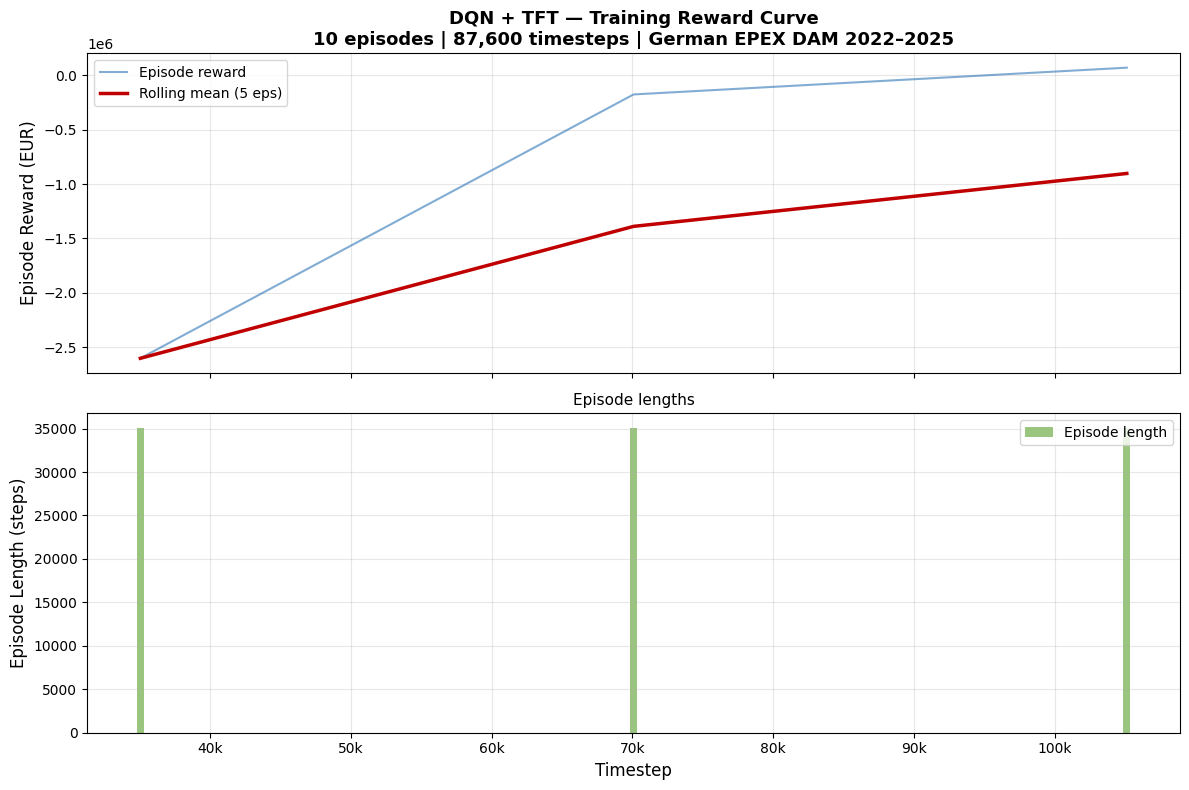

Saved: /content/drive/MyDrive/thesis_battery_xrl/tft_outputs/dqn_tft_training_curve.png


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Load training monitor log ─────────────────────────────────────
monitor_path = '/content/drive/MyDrive/thesis_battery_xrl/rl_outputs/dqn_tft/dqn/run_0/train_monitor.csv'

# SB3 monitor CSV has a commented header line — skip it
monitor_df = pd.read_csv(monitor_path, comment='#')
print(f'Columns: {monitor_df.columns.tolist()}')
print(f'Rows: {len(monitor_df):,}')
print(monitor_df.head())

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Cumulative timesteps
monitor_df['timestep'] = monitor_df['l'].cumsum()

# ── Episode reward ────────────────────────────────────────────────
ax = axes[0]
ax.plot(monitor_df['timestep'], monitor_df['r'],
        color='#2E75B6', linewidth=1.5, alpha=0.6, label='Episode reward')

# Rolling mean over 5 episodes
rolling = monitor_df['r'].rolling(window=5, min_periods=1).mean()
ax.plot(monitor_df['timestep'], rolling,
        color='#C00000', linewidth=2.5, label='Rolling mean (5 eps)')

ax.set_ylabel('Episode Reward (EUR)', fontsize=12)
ax.set_title('DQN + TFT — Training Reward Curve\n'
             '10 episodes | 87,600 timesteps | German EPEX DAM 2022–2025',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# ── Episode length ────────────────────────────────────────────────
ax2 = axes[1]
ax2.bar(monitor_df['timestep'], monitor_df['l'],
        color='#70AD47', alpha=0.7, width=500, label='Episode length')
ax2.set_xlabel('Timestep', fontsize=12)
ax2.set_ylabel('Episode Length (steps)', fontsize=12)
ax2.set_title('Episode lengths', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
save_path = f'{DRIVE_SAVE_DIR}/dqn_tft_training_curve.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

**Stage 3: Explainability Layer**

Loaded: /content/drive/MyDrive/thesis_battery_xrl/rl_outputs/dqn_tft/dqn/run_0/best_model.zip
Feature dims: 93
Device: cuda:0



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Background shape: (200, 93)

Running evaluation episode...
Episode: 35040 steps | total reward = 76,571.71 EUR

Running DeepSHAP...
SHAP rows: 730

Top 10 features:
          feature  mean_abs_shap   group
           IDM_t1       0.066633     IDM
DAM_IDM_spread_t1       0.034920     IDM
      tft_p50_h02       0.007600 TFT p50
      tft_p90_h06       0.006514 TFT p90
      tft_p90_h13       0.006423 TFT p90
      tft_p50_h11       0.005252 TFT p50
      tft_p50_h22       0.005241 TFT p50
      tft_p50_h19       0.005045 TFT p50
      tft_p50_h09       0.004705 TFT p50
      tft_p90_h08       0.004672 TFT p90


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


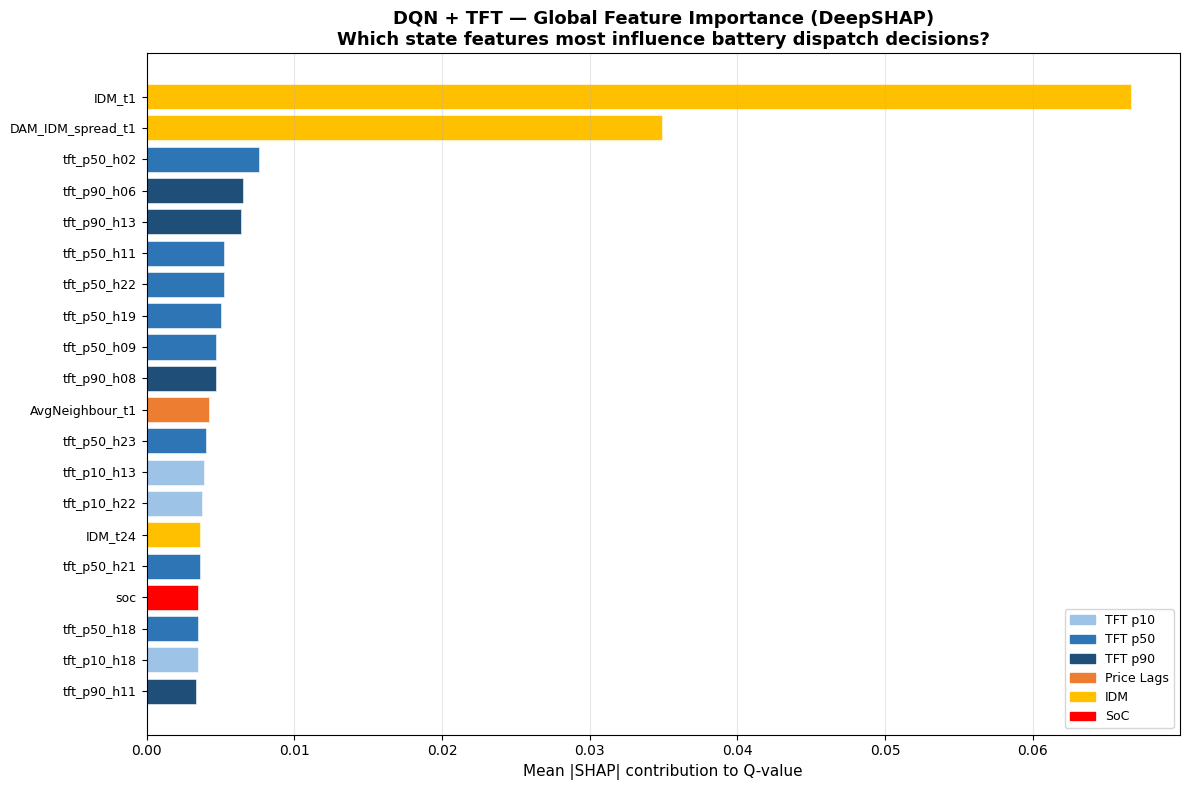

Saved: /content/drive/MyDrive/thesis_battery_xrl/xrl_outputs/v1_dqn_tft_global_importance.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


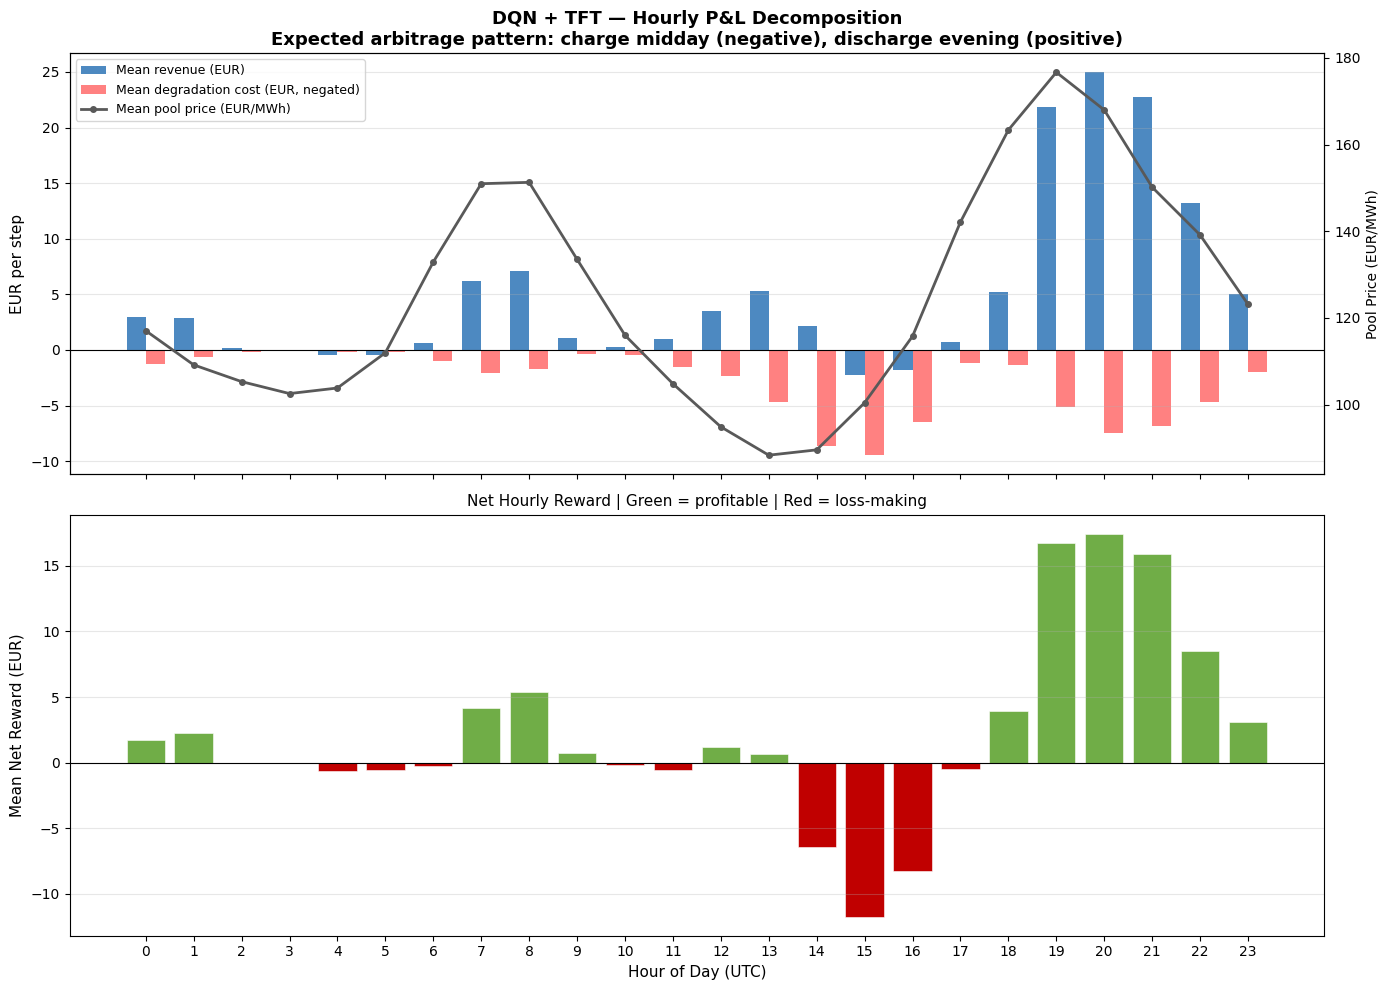

Saved: /content/drive/MyDrive/thesis_battery_xrl/xrl_outputs/v2_dqn_tft_hourly_pnl.png

Stage 3 DQN+TFT analysis complete.
V1: /content/drive/MyDrive/thesis_battery_xrl/xrl_outputs/v1_dqn_tft_global_importance.png
V2: /content/drive/MyDrive/thesis_battery_xrl/xrl_outputs/v2_dqn_tft_hourly_pnl.png


In [45]:
# ═══════════════════════════════════════════════════════════════════
# STAGE 3 — XRL: DQN+TFT Full Analysis (SHAP + Hourly P&L)
# Complete self-contained cell with all fixes applied
# ═══════════════════════════════════════════════════════════════════
!pip install -q shap

import os, sys
import numpy as np
import pandas as pd
import torch
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from gymnasium.wrappers import FlattenObservation
from pathlib import Path
from stable_baselines3 import DQN
from envs.environments import FreeBatteryEnv
from envs.env_params import GERMAN_BATTERY, GERMAN_STATE_VARS

os.chdir('/content/XRL-for-optimising-battery-schedules')
sys.path.insert(0, '/content/XRL-for-optimising-battery-schedules')

# ── Config ────────────────────────────────────────────────────────
CKPT_PATH = '/content/drive/MyDrive/thesis_battery_xrl/rl_outputs/dqn_tft/dqn/run_0/best_model.zip'
XRL_OUT   = Path('/content/drive/MyDrive/thesis_battery_xrl/xrl_outputs')
XRL_OUT.mkdir(parents=True, exist_ok=True)

DISCRETE_TO_CONTINUOUS = {
    0: np.array([-1.0], dtype=np.float32),
    1: np.array([-0.5], dtype=np.float32),
    2: np.array([ 0.0], dtype=np.float32),
    3: np.array([ 0.5], dtype=np.float32),
    4: np.array([ 1.0], dtype=np.float32),
}

action_names = [
    'discharge_full',
    'discharge_half',
    'hold',
    'charge_half',
    'charge_full',
]

group_colours = {
    'TFT p10':    '#9DC3E6',
    'TFT p50':    '#2E75B6',
    'TFT p90':    '#1F4E79',
    'Price Lags': '#ED7D31',
    'IDM':        '#FFC000',
    'Wind':       '#70AD47',
    'Solar':      '#FFD966',
    'Load':       '#7030A0',
    'Cyclic':     '#00B0F0',
    'SoC':        '#FF0000',
    'Other':      '#808080',
}

def feature_group(f):
    if 'tft_p10' in f:   return 'TFT p10'
    if 'tft_p50' in f:   return 'TFT p50'
    if 'tft_p90' in f:   return 'TFT p90'
    if 'DAM_t'   in f:   return 'Price Lags'
    if 'Neighbour' in f: return 'Price Lags'
    if 'IDM'     in f:   return 'IDM'
    if 'Wind'    in f:   return 'Wind'
    if 'Solar'   in f:   return 'Solar'
    if 'load'    in f.lower() or 'Load' in f: return 'Load'
    if 'sin'     in f or 'cos' in f: return 'Cyclic'
    if 'soc'     in f:   return 'SoC'
    return 'Other'

# ── 1. Load model ─────────────────────────────────────────────────
model = DQN.load(CKPT_PATH)
print(f'Loaded: {CKPT_PATH}')

# ── 2. Build environment ──────────────────────────────────────────
TFT_STATE_VARS = GERMAN_STATE_VARS + \
    [f'tft_p10_h{h:02d}' for h in range(24)] + \
    [f'tft_p50_h{h:02d}' for h in range(24)] + \
    [f'tft_p90_h{h:02d}' for h in range(24)]

de_bat_tft_eval = {
    'env_name':          'de_bat_tft_eval',
    'data_file':         TFT_CSV,
    'state_vars':        TFT_STATE_VARS,
    'grid':              dict(demand_profile=None),
    'storage':           dict(**GERMAN_BATTERY),
    'resolution_h':      1.0,
    'modeling_period_h': 8760,
    'tft_24h':           None,
}

env_flat = FlattenObservation(FreeBatteryEnv(**de_bat_tft_eval))
raw_env  = env_flat.env

feature_names = ['soc'] + TFT_STATE_VARS
print(f'Feature dims: {len(feature_names)}')  # expect 93

# ── 3. Q-network ──────────────────────────────────────────────────
q_net  = model.policy.q_net.eval()
device = next(q_net.parameters()).device
print(f'Device: {device}')

# ── 4. Collect background states ──────────────────────────────────
print('\nCollecting background states...')
obs, _ = env_flat.reset()
background = []

for _ in range(200):
    a, _   = model.predict(obs, deterministic=True)
    background.append(obs.astype(np.float32))
    cont_a = DISCRETE_TO_CONTINUOUS[int(a)]
    obs, _, done, _, _ = env_flat.step(cont_a)
    if done:
        obs, _ = env_flat.reset()

background = np.array(background, dtype=np.float32)
print(f'Background shape: {background.shape}')

# ── 5. Run evaluation episode ─────────────────────────────────────
print('\nRunning evaluation episode...')
obs, _ = env_flat.reset()
done   = False
t      = 0

all_states, all_actions, all_rewards = [], [], []
all_e_sales, all_degr, all_prices, all_socs = [], [], [], []

while not done:
    a, _ = model.predict(obs, deterministic=True)
    a    = int(a)

    all_states.append(obs.astype(np.float32))
    all_actions.append(a)
    all_socs.append(float(raw_env.storage.soc))
    all_prices.append(float(raw_env.data.iloc[raw_env.count]['pool_price']))

    cont_a = DISCRETE_TO_CONTINUOUS[a]
    obs, rew, done, _, _ = env_flat.step(cont_a)
    rew = float(rew)
    all_rewards.append(rew)

    dc = float(raw_env.storage.degr_costs[-1]) if raw_env.storage.degr_costs else 0.0
    all_e_sales.append(rew + dc)
    all_degr.append(dc)
    t += 1

print(f'Episode: {t} steps | total reward = {sum(all_rewards):,.2f} EUR')

# ── 6. DeepSHAP ───────────────────────────────────────────────────
print('\nRunning DeepSHAP...')
shap_rows    = []
sample_steps = range(0, len(all_states), 48)

for action_idx in range(5):
    class _ActionWrapper(torch.nn.Module):
        def __init__(self, net, idx):
            super().__init__()
            self.net = net
            self.idx = idx
        def forward(self, x):
            return self.net(x)[:, self.idx:self.idx+1]

    wrapper   = _ActionWrapper(q_net, action_idx).to(device).eval()
    bg_tensor = torch.FloatTensor(background).to(device)
    explainer = shap.DeepExplainer(wrapper, bg_tensor)

    for step_idx in sample_steps:
        if all_actions[step_idx] != action_idx:
            continue
        s  = all_states[step_idx]
        t_ = torch.FloatTensor(s).unsqueeze(0).to(device)
        sv = explainer.shap_values(t_, check_additivity=False)  # fix
        if isinstance(sv, list):
            sv = sv[0]
        shap_rows.append({
            'step':   step_idx,
            'action': action_names[action_idx],
            **dict(zip(feature_names, np.array(sv).flatten()))
        })

shap_df    = pd.DataFrame(shap_rows)
importance = shap_df[feature_names].abs().mean().sort_values(ascending=False)

imp_df = pd.DataFrame({
    'feature':       importance.index,
    'mean_abs_shap': importance.values,
    'group':         [feature_group(f) for f in importance.index],
}).reset_index(drop=True)

print(f'SHAP rows: {len(shap_df)}')
print('\nTop 10 features:')
print(imp_df.head(10)[['feature', 'mean_abs_shap', 'group']].to_string(index=False))

# ── 7. Visualisation 1: Global Feature Importance ─────────────────
top_n = 20
top   = imp_df.head(top_n)
cols  = [group_colours.get(g, '#808080') for g in top['group']]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(top_n), top['mean_abs_shap'].values,
        color=cols, edgecolor='white', linewidth=0.4)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP| contribution to Q-value', fontsize=11)
ax.set_title(
    'DQN + TFT — Global Feature Importance (DeepSHAP)\n'
    'Which state features most influence battery dispatch decisions?',
    fontsize=13, fontweight='bold'
)
legend_patches = [
    mpatches.Patch(color=c, label=g)
    for g, c in group_colours.items()
    if g in top['group'].values
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

v1_path = str(XRL_OUT / 'v1_dqn_tft_global_importance.png')
plt.savefig(v1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {v1_path}')

# ── 8. Visualisation 2: Hourly P&L Decomposition ─────────────────
step_df = pd.DataFrame({
    'hour':       [i % 24 for i in range(len(all_rewards))],
    'e_sales':    all_e_sales,
    'degr_cost':  all_degr,
    'reward':     all_rewards,
    'pool_price': all_prices,
    'soc':        all_socs,
    'action':     [action_names[a] for a in all_actions],
})

hourly = step_df.groupby('hour').agg(
    mean_revenue  = ('e_sales',    'mean'),
    mean_degr     = ('degr_cost',  'mean'),
    mean_reward   = ('reward',     'mean'),
    mean_price    = ('pool_price', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
hours = hourly['hour'].values

ax = axes[0]
ax.bar(hours - 0.2, hourly['mean_revenue'].values,
       width=0.4, color='#2E75B6', alpha=0.85, label='Mean revenue (EUR)')
ax.bar(hours + 0.2, -hourly['mean_degr'].values,
       width=0.4, color='#FF6B6B', alpha=0.85,
       label='Mean degradation cost (EUR, negated)')
ax.axhline(y=0, color='black', linewidth=0.8)
ax2 = ax.twinx()
ax2.plot(hours, hourly['mean_price'].values,
         color='#595959', linewidth=2, marker='o',
         markersize=4, label='Mean pool price (EUR/MWh)')
ax2.set_ylabel('Pool Price (EUR/MWh)', fontsize=10)
ax.set_ylabel('EUR per step', fontsize=11)
ax.set_title(
    'DQN + TFT — Hourly P&L Decomposition\n'
    'Expected arbitrage pattern: charge midday (negative), '
    'discharge evening (positive)',
    fontsize=13, fontweight='bold'
)
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
reward_cols = ['#70AD47' if r >= 0 else '#C00000'
               for r in hourly['mean_reward'].values]
ax.bar(hours, hourly['mean_reward'].values,
       color=reward_cols, edgecolor='white', linewidth=0.4)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Mean Net Reward (EUR)', fontsize=11)
ax.set_xlabel('Hour of Day (UTC)', fontsize=11)
ax.set_title(
    'Net Hourly Reward | Green = profitable | Red = loss-making',
    fontsize=11
)
ax.set_xticks(range(24))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
v2_path = str(XRL_OUT / 'v2_dqn_tft_hourly_pnl.png')
plt.savefig(v2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {v2_path}')

print('\n' + '='*55)
print('Stage 3 DQN+TFT analysis complete.')
print(f'V1: {v1_path}')
print(f'V2: {v2_path}')
print('='*55)